#  Preprocessing

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 61.5 MB/s eta 0:00:00


In [ ]:
!pip install pyprep

In [ ]:
!pip install -U autoreject

In [ ]:
import os
import random
from itertools import chain
import numpy as np
import pandas as pd
from scipy import signal
from scipy.interpolate import interp1d
from scipy.special import rel_entr
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import LabelEncoder
from autoreject import AutoReject
import mne
from mne.datasets import sample
from mne.viz import plot_topomap
from pyprep.find_noisy_channels import NoisyChannels
import matplotlib.pyplot as plt
import kagglehub

## I.Introduction

EEG, or electroencephalography, is a technique used to record electrical activity from the brain. It is most commonly performed non-invasively, using electrodes placed on the scalp. However, in certain clinical neurological cases, such as epilepsy, EEG may also be recorded invasively using electrodes placed directly on the surface of the brain.

An EEG system typically employs between 1 and 250 electrodes. Even at the higher end of this range, it is evident that the number of electrodes is far fewer than the estimated 80 billion neurons in the brain. Additionally, the skull serves as a poor conductor of electricity. As a result, the signals captured by EEG represent the aggregated activity of large groups of neurons working together, rather than the activity of individual neurons.

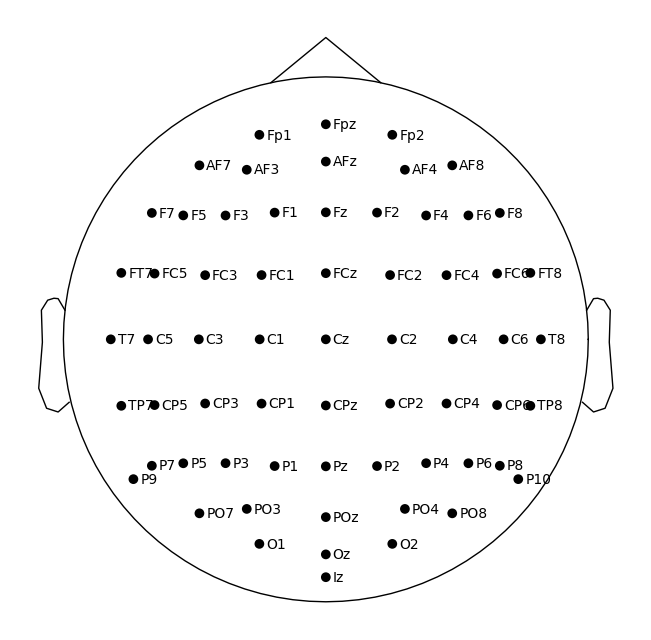

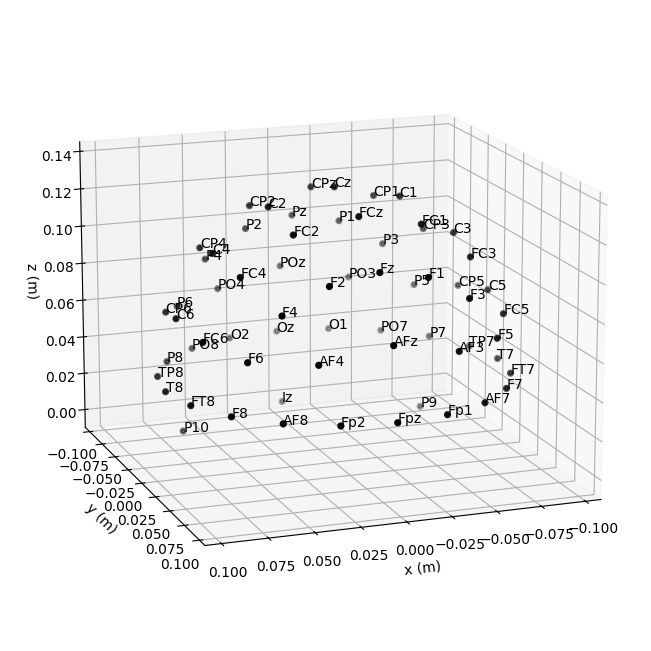

In [ ]:
visualize_montage = mne.channels.make_standard_montage('biosemi64')
visualize_montage.plot()  # 2D
fig = visualize_montage.plot(kind="3d", show=False)  # 3D
fig = fig.gca().view_init(azim=70, elev=15)  # set view angle for tutorial

## II. Extract raw data

In [ ]:
data_root = '../input/eeg-data-for-mental-attention-state-detection/eeg data/EEG Data/'

files = os.listdir(data_root)

mat = scipy.io.loadmat(data_root + files[1])

mat['o']['sampFreq'][0][0][0][0]

data = mat['o']['data'][0, 0]
FS = mat['o']['sampFreq'][0][0][0][0]

data

In [ ]:
channel_indices = np.array(range(3, 17))
channel_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
channel_map = dict(zip(channel_names, channel_indices))

In [ ]:
data = []

for subject_idx in range(1, 35):
    states = get_data(f"eeg_record{subject_idx}.mat")

    for state, eeg in states.items():
        num_samples = eeg.shape[0]
        for sample_idx in range(num_samples):
            row = {
                'state': state,
                'subject': f"subject_{subject_idx}",
            }

            for ch_name, ch_idx in channel_map.items():
                row[ch_name] = eeg[sample_idx, ch_idx]
            data.append(row)
df = pd.DataFrame(data)



## III. Import library & download data

In [ ]:
import kagglehub
khoivudang1209_eeg_data_path = kagglehub.dataset_download('khoivudang1209/eeg-data')

print('Data source import complete.')


Data source import complete.


In [ ]:
!ls $khoivudang1209_eeg_data_path

eeg_powers.csv


In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)


In [ ]:
data = pd.read_csv(f"{khoivudang1209_eeg_data_path}/eeg_powers.csv")

In [ ]:
subjects = [
    'subject_1', 'subject_2', 'subject_8', 'subject_9',
    'subject_15', 'subject_16', 'subject_23', 'subject_24',
    'subject_30', 'subject_31'
]

data = data[~data['subject'].isin(subjects)]

In [ ]:
data = data.drop(data.columns[0], axis=1)

In [ ]:
def pandas_to_mne(df, sfreq, channel_types=None, ch_names=None):
    if ch_names is None:
        ch_names = df.columns.tolist()
    if channel_types is None:
        channel_types = ['eeg'] * len(ch_names)  # Default to 'misc' type channels

    if len(ch_names) != df.shape[1]:
        raise ValueError("Number of channel names must match the number of columns in the DataFrame.")
    if len(channel_types) != len(ch_names):
        raise ValueError("Number of channel types must match the number of channels.")

    data = df.values.T

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=channel_types)
    raw = mne.io.RawArray(data, info)

    return raw

In [ ]:
encoder = LabelEncoder()

data['state'] = encoder.fit_transform(data['state'])

In [ ]:
subject = 'subject_10'
df = data[data['subject'] == subject]
label_data=df['state']

In [ ]:
df=df.drop(['subject','state'],axis=1)

In [ ]:
df.columns

Index(['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6',
       'F4', 'F8', 'AF4'],
      dtype='object')

In [ ]:
n_channels = 14
n_samples = len(df)
sfreq = 128
raw = pandas_to_mne(df, sfreq)
montage = mne.channels.make_standard_montage('standard_1020')  # Adjust as needed
raw.set_montage(montage)
raw.pick_types(eeg=True)

Creating RawArray with float64 data, n_channels=14, n_times=304540
    Range : 0 ... 304539 =      0.000 ...  2379.211 secs
Ready.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<RawArray | 14 x 304540 (2379.2 s), ~32.6 MB, data loaded>

## IV. EDA & Data mining

### 1. EDA

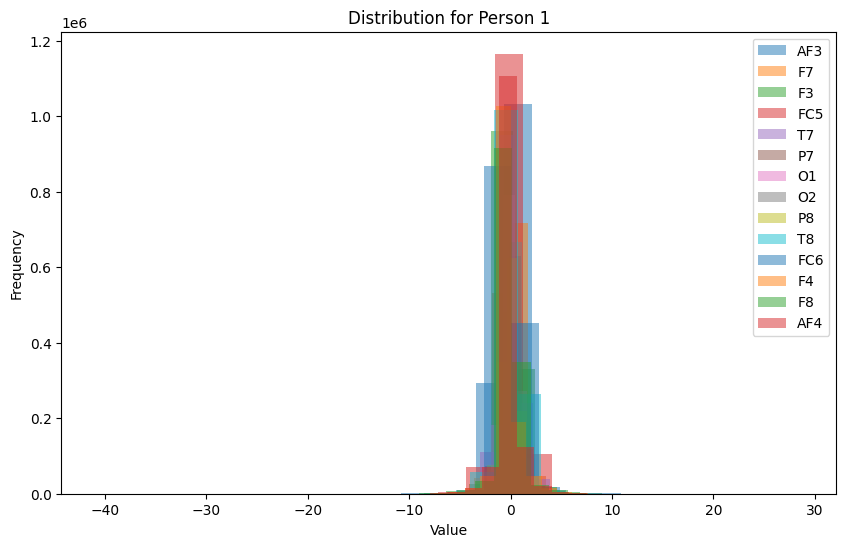

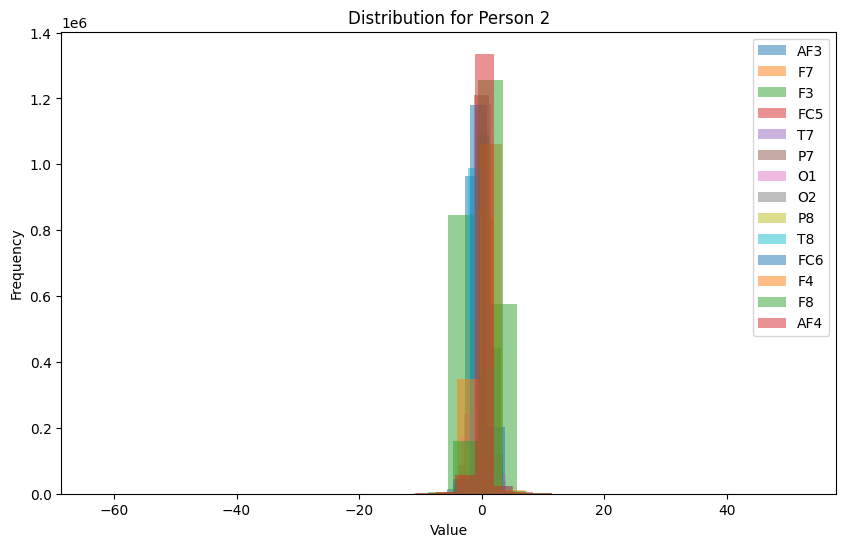

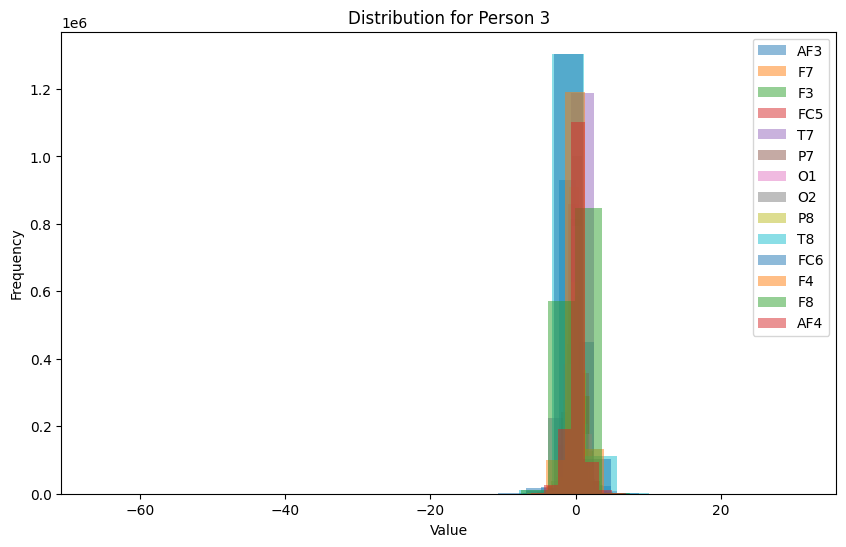

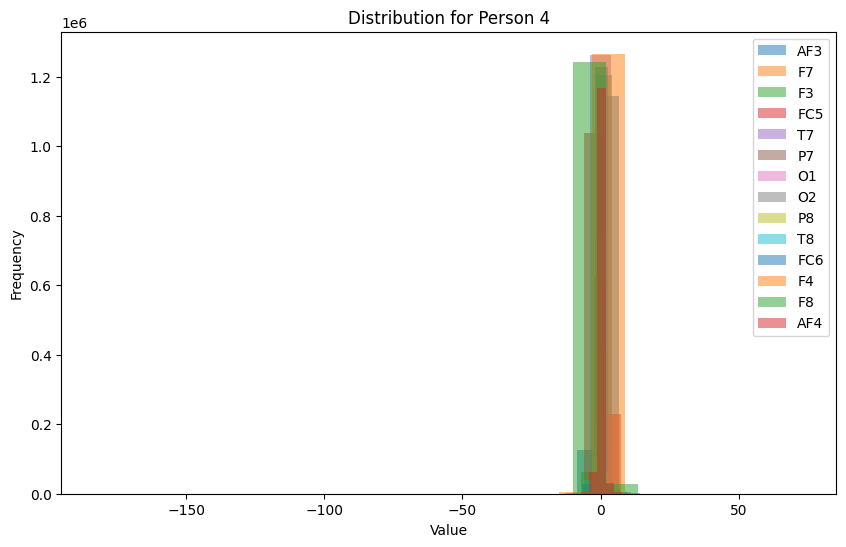

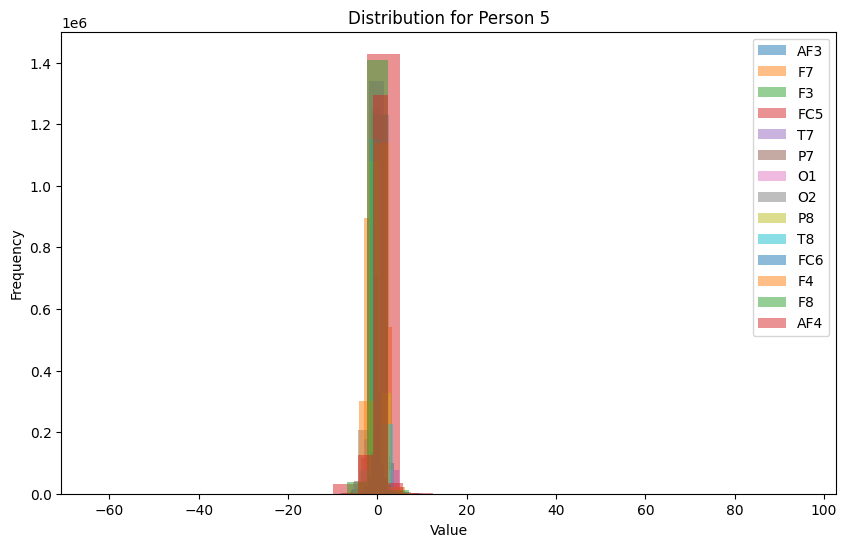

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

for i, group in enumerate(data):
    plt.figure(figsize=(10, 6))

    df_channel = pd.DataFrame()
    for df in group:

        if 'state' in df.columns:
            df = df.drop('state', axis=1)
        df_channel = pd.concat([df_channel, df], ignore_index=True)

    df_channel = (df_channel - df_channel.mean()) / df_channel.std()

    for col in df_channel.columns:
        plt.hist(df_channel[col], bins=20, alpha=0.5, label=col)

    plt.title(f"Distribution for Person {i+1}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


The distribution data for each channel per person has the same pattern.

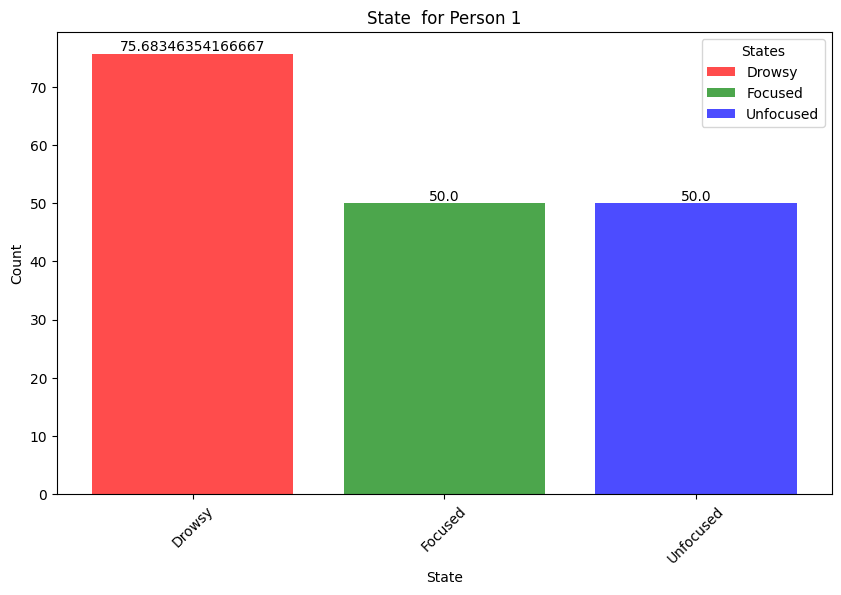

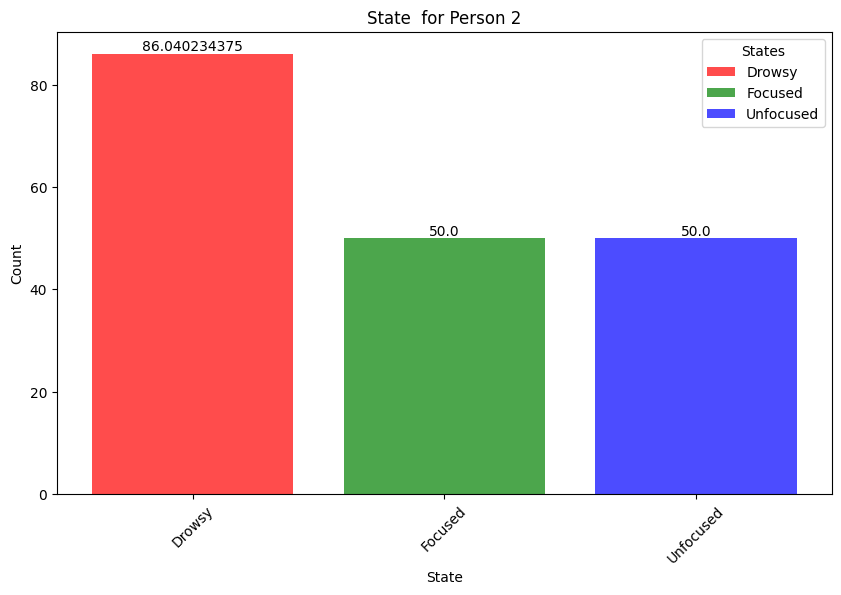

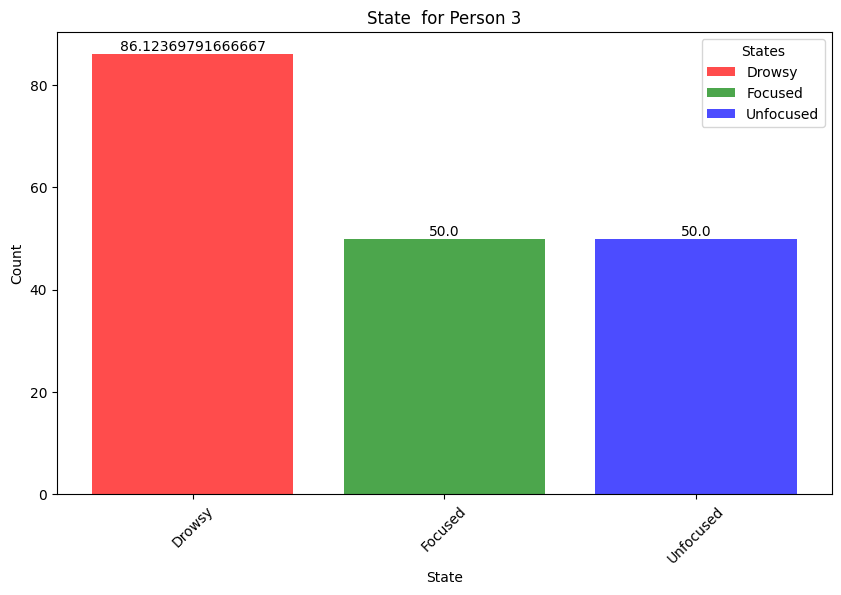

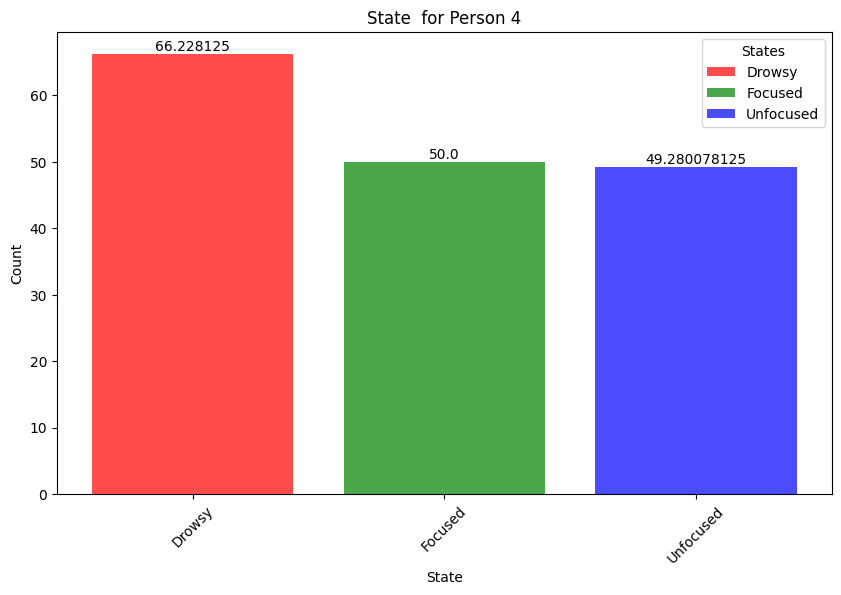

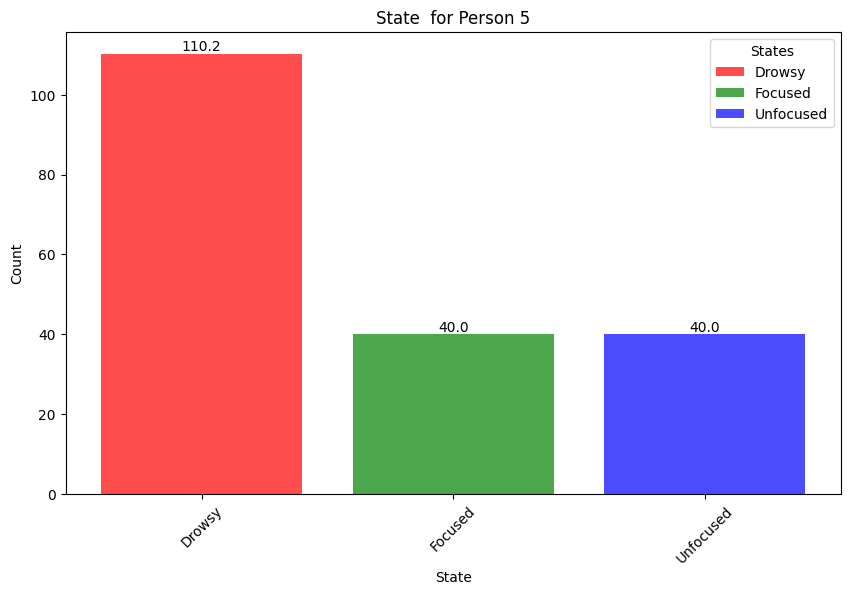

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# State labels
state_labels = {0: "Drowsy", 1: "Focused", 2: "Unfocused"}

for i, group in enumerate(data):
    plt.figure(figsize=(10, 6))

    df_channel = pd.DataFrame()
    for df in group:
        if 'state' in df.columns:
            df_channel = pd.concat([df_channel, df], ignore_index=True)

    state_counts = df_channel['state'].value_counts()/(128*60)

    bars = plt.bar(state_counts.index, state_counts.values, alpha=0.7, color=['red', 'green', 'blue'])

    # Add labels to each bar
    for bar, count in zip(bars, state_counts.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.legend(
        [bars[0], bars[1], bars[2]],
        [state_labels[0], state_labels[1], state_labels[2]],
        title="States"
    )

    plt.title(f"State  for Person {i+1}")
    plt.xlabel("State")
    plt.ylabel("Count")
    plt.xticks(state_counts.index, [state_labels.get(state, state) for state in state_counts.index], rotation=45)
    plt.show()


Person 5 spent the most time with measured brain waves in the drowsy state compared to other individuals. However, Person 5 has less total time of measured brain waves than others because their data was recorded for only 4 days, one day less than the other individuals.

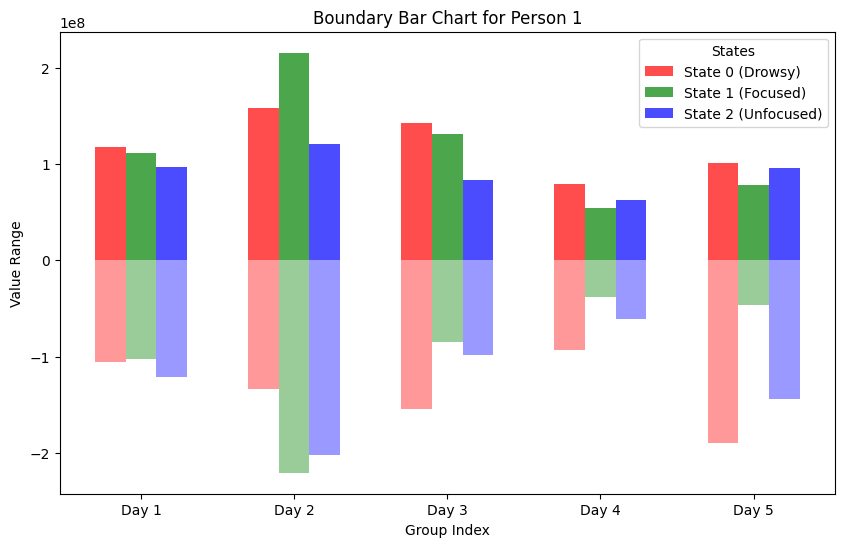

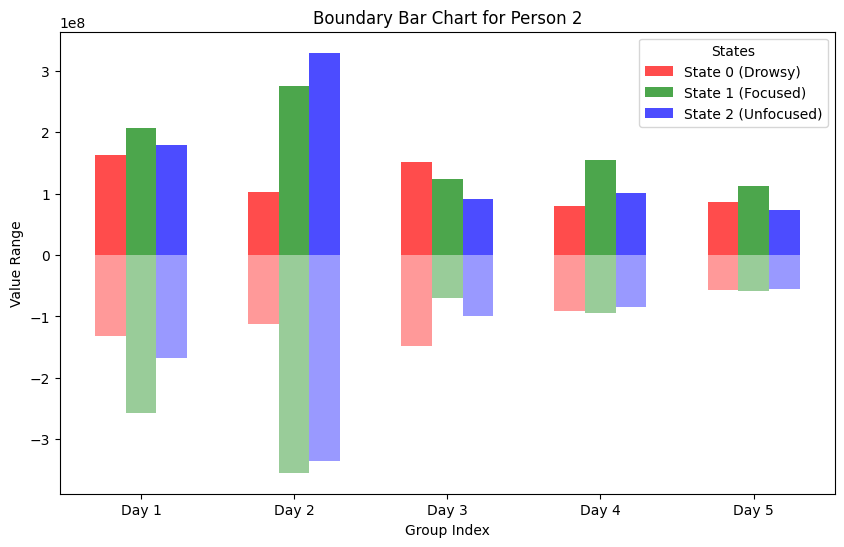

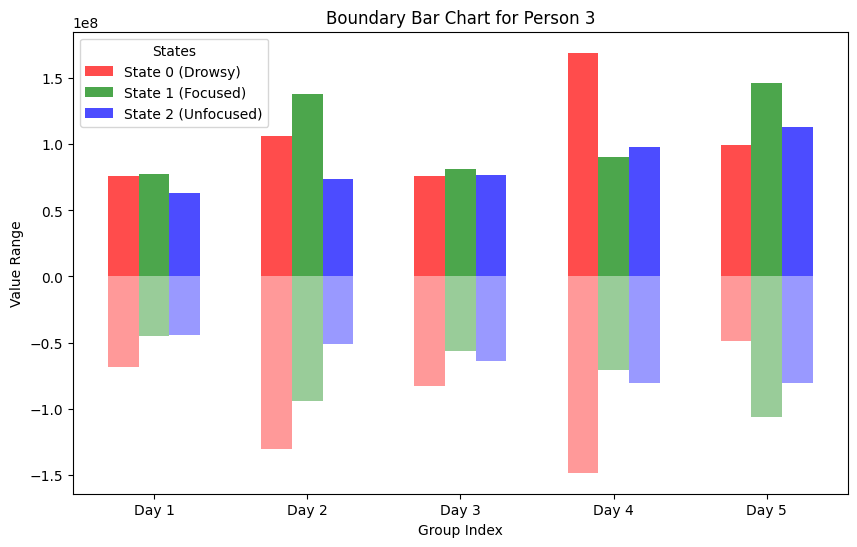

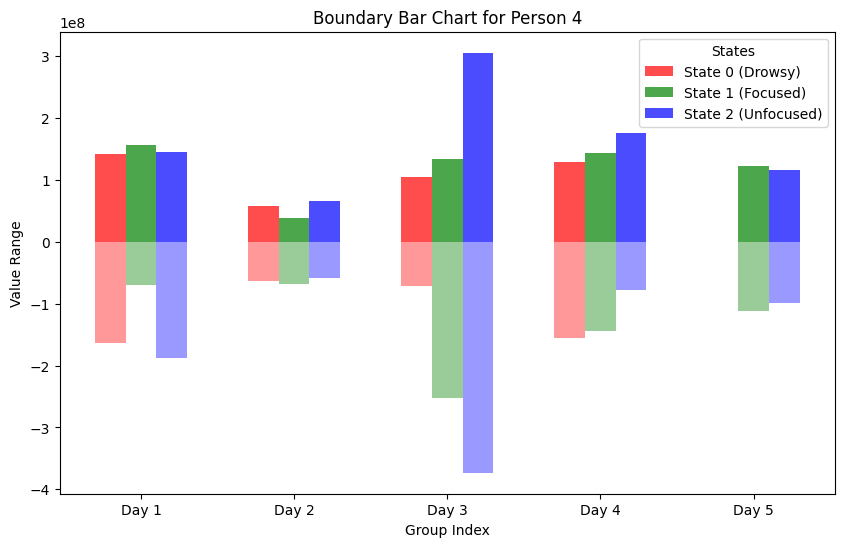

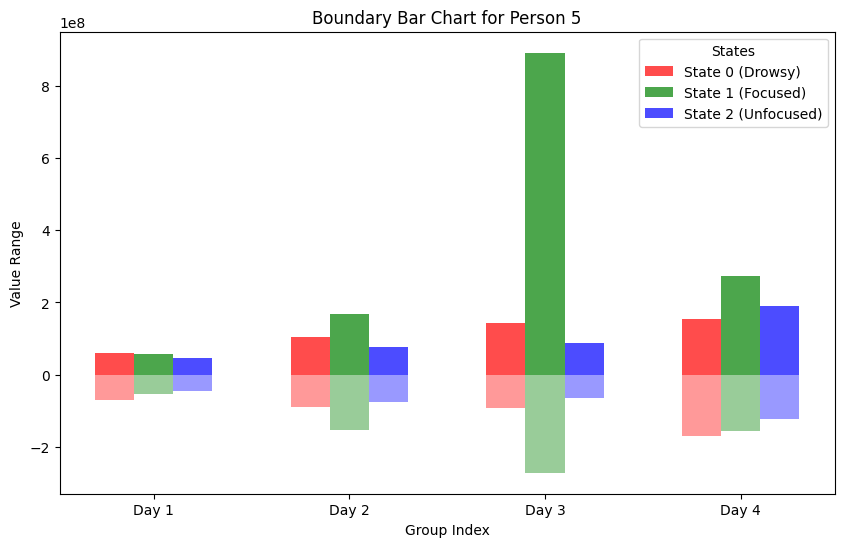

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


for i, group in enumerate(data):
    plt.figure(figsize=(10, 6))

    state_boundaries = {0: [], 1: [], 2: []}

    for df in group:
        if 'state' in df.columns:
            for state in [0, 1, 2]:
                state_data = df[df['state'] == state].drop(columns=['state'], errors='ignore')
                if not state_data.empty:

                    state_min = state_data.min().min()
                    state_max = state_data.max().max()
                    state_boundaries[state].append((state_min, state_max))
                else:

                    state_boundaries[state].append((np.nan, np.nan))

    bar_width = 0.2
    x_positions = np.arange(len(group))


    colors = {0: 'red', 1: 'green', 2: 'blue'}
    labels = {0: "Drowsy", 1: "Focused", 2: "Unfocused"}

    for state, boundaries in state_boundaries.items():
        min_values = [b[0] if not np.isnan(b[0]) else 0 for b in boundaries]
        max_values = [b[1] if not np.isnan(b[1]) else 0 for b in boundaries]

        # Plot bars
        plt.bar(x_positions + state * bar_width, max_values, bar_width,
                label=f"State {state} ({labels[state]})", color=colors[state], alpha=0.7)
        plt.bar(x_positions + state * bar_width, min_values, bar_width,
                color=colors[state], alpha=0.4)

    plt.title(f"Boundary Bar Chart for Person {i+1}")
    plt.xlabel("Group Index")
    plt.ylabel("Value Range")
    plt.xticks(x_positions + bar_width, [f"Day {j+1}" for j in range(len(group))])
    plt.legend(title="States")
    plt.show()



"The range for Person 3 doesn't change much between each day, so the model might work better for Person 3 compared to the other individual."

In [ ]:
df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
2514704,4435.897436,4027.692308,5087.179487,3826.666667,4035.384615,4404.102564,4366.666667,4125.641026,4217.435897,4308.205128,4142.564103,4283.589744,4334.871795,4158.974359
2514705,4437.948718,4028.717949,5085.128205,3818.974359,4035.897436,4404.615385,4368.717949,4125.128205,4218.974359,4308.717949,4140.512821,4283.589744,4334.871795,4151.794872
2514706,4440.512821,4034.871795,5090.256410,3815.384615,4035.384615,4413.846154,4369.743590,4136.923077,4227.179487,4308.717949,4142.564103,4283.589744,4333.846154,4156.923077
2514707,4441.538462,4028.717949,5088.205128,3820.512821,4034.871795,4405.641026,4367.179487,4131.794872,4220.000000,4308.205128,4143.076923,4283.589744,4334.871795,4155.384615
2514708,4440.000000,4019.487179,5077.435897,3825.641026,4036.923077,4391.794872,4365.641026,4117.948718,4212.307692,4308.205128,4137.435897,4283.589744,4335.384615,4147.179487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2819239,4437.948718,3967.692308,5052.307692,3828.717949,4035.384615,4304.102564,4324.102564,4037.435897,4091.794872,4304.102564,4118.461538,4283.589744,4334.871795,4176.923077
2819240,4434.871795,3957.435897,5040.512821,3832.820513,4036.410256,4295.897436,4317.435897,4023.589744,4083.076923,4304.615385,4210.256410,4283.076923,4335.897436,4166.666667
2819241,4436.923077,3957.435897,5036.410256,3830.769231,4035.897436,4294.871795,4315.384615,4022.051282,4073.846154,4304.102564,4236.923077,4283.589744,4333.846154,4166.153846
2819242,4436.410256,3956.923077,5037.948718,3830.256410,4037.948718,4295.384615,4314.871795,4027.692308,4078.461538,4304.102564,4223.076923,4283.589744,4332.820513,4167.179487


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304540 entries, 2514704 to 2819243
Data columns (total 14 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AF3     304540 non-null  float64
 1   F7      304540 non-null  float64
 2   F3      304540 non-null  float64
 3   FC5     304540 non-null  float64
 4   T7      304540 non-null  float64
 5   P7      304540 non-null  float64
 6   O1      304540 non-null  float64
 7   O2      304540 non-null  float64
 8   P8      304540 non-null  float64
 9   T8      304540 non-null  float64
 10  FC6     304540 non-null  float64
 11  F4      304540 non-null  float64
 12  F8      304540 non-null  float64
 13  AF4     304540 non-null  float64
dtypes: float64(14)
memory usage: 34.9 MB


In [ ]:
df.describe()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
count,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000,304540.000000
mean,4437.967246,3976.470002,5035.915173,3827.566266,4036.232751,4319.753106,4284.376762,4039.426341,4157.667909,4307.575708,4141.749101,4282.645160,4334.666470,4130.160481
std,2.204611,38.185845,57.585140,2.543644,1.810403,48.838867,64.692979,55.136835,49.219884,2.143473,5.192763,1.130800,1.195119,52.848392
min,4389.230769,3750.769231,4633.846154,3795.384615,4016.410256,3985.641026,3909.743590,3671.794872,3846.153846,4294.358974,3954.358974,4261.538462,4311.282051,3735.897436
25%,4436.410256,3960.512821,5018.461538,3826.153846,4034.871795,4302.564103,4262.564103,4018.974359,4135.897436,4306.666667,4140.512821,4282.051282,4334.358974,4111.282051
50%,4437.948718,3977.435897,5041.538462,3827.692308,4035.897436,4327.179487,4283.589744,4042.051282,4154.871795,4308.205128,4141.538462,4282.564103,4334.871795,4136.923077
75%,4439.487179,3994.871795,5062.564103,3829.230769,4036.923077,4347.179487,4310.256410,4062.564103,4175.384615,4308.205128,4143.076923,4283.076923,4335.384615,4155.897436
max,4490.769231,4280.512821,5267.692308,3838.461538,4053.333333,4573.846154,4695.897436,4386.153846,4475.384615,4342.051282,4372.820513,4304.615385,4350.769231,4832.307692


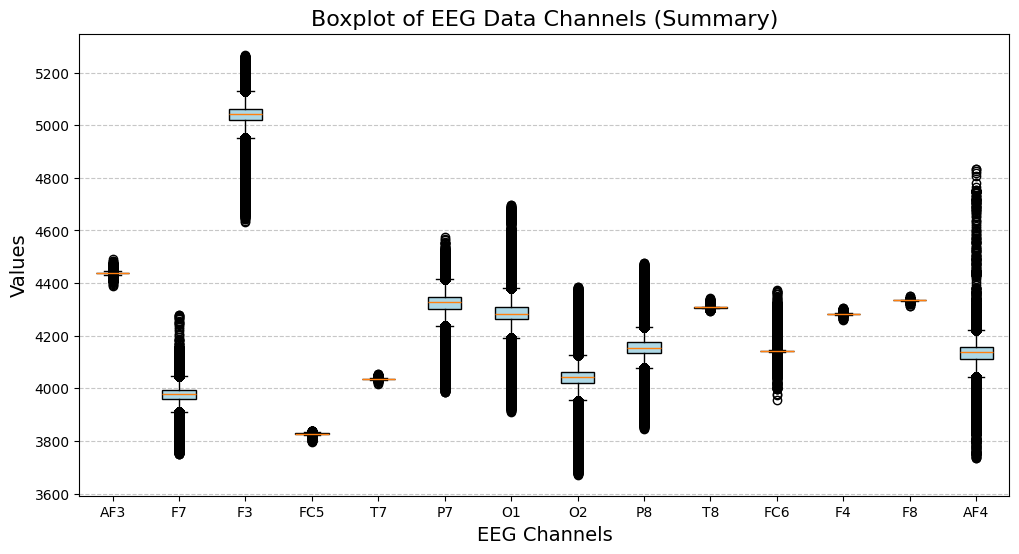

In [ ]:
summary_stats = df.describe(percentiles=[0.25, 0.5, 0.75]).T
summary_stats['iqr'] = summary_stats['75%'] - summary_stats['25%']

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([df[col] for col in df.columns], labels=df.columns, patch_artist=True,
           boxprops=dict(facecolor="lightblue"))

plt.title("Boxplot of EEG Data Channels (Summary)", fontsize=16)
plt.ylabel("Values", fontsize=14)
plt.xlabel("EEG Channels", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observations

Channel Variability:
- Channels such as 'AF4', 'O1', 'O2', and 'F7' have a broader range of values (taller boxes and longer whiskers) compared to channels like 'T7' and 'T8', which have more tightly clustered values.
- This suggests that certain channels are capturing more variable brain activity than others.

Outliers:
- Most channels show a significant number of outliers (black dots), indicating that some data points deviate substantially from the main distribution.
- Channels like 'AF4' and 'O2' have particularly prominent outliers.

Median Value Differences:
- The median values differ across channels, reflecting variations in the baseline activity levels recorded by different electrodes. For instance: Channels like 'AF3', 'F7', and 'AF4' have higher medians compared to 'T7' and 'T8'.

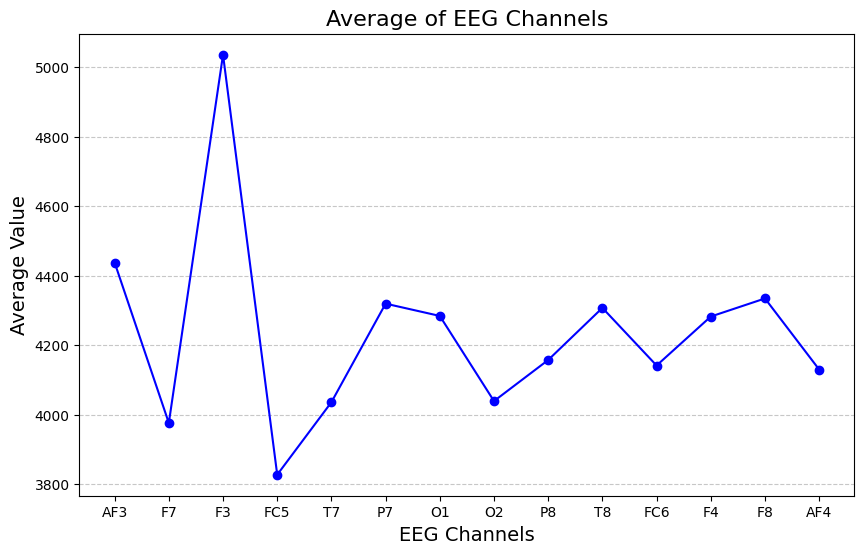

In [ ]:
column_means = df.mean()

plt.figure(figsize=(10, 6))
plt.plot(df.columns, column_means, marker='o', linestyle='-', color='b')

plt.title("Average of EEG Channels", fontsize=16)
plt.ylabel("Average Value", fontsize=14)
plt.xlabel("EEG Channels", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observations

Channel with the Highest Average (F7):

- The F7 channel stands out with the highest average value (around 5000). This indicates that this electrode recorded higher signal intensities on average compared to others.

Channel with the Lowest Average (FC5):

- The FC5 channel shows the lowest average value (approximately 3800). This means that the signals from this channel were consistently lower than those of other channels.

Fluctuations Across Channels:

- The average values vary significantly across channels, reflecting differences in signal intensity recorded from various scalp locations.

- For example, channels like 'AF3', 'P7', 'O1', and 'O2' show intermediate average values, while channels like 'T8' and 'FC6' are on the lower end.

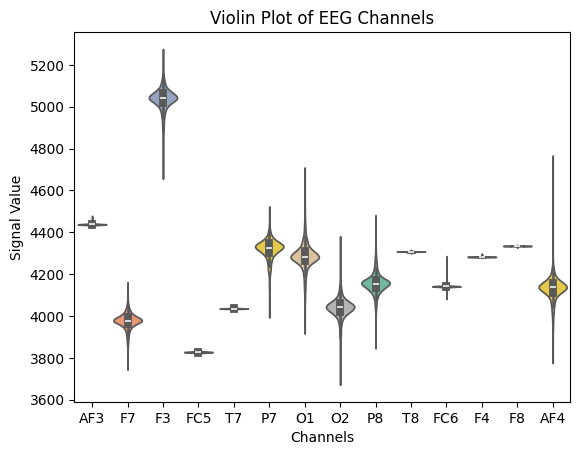

In [ ]:
downsampled_df = df.iloc[::100]

sns.violinplot(data=downsampled_df, palette="Set2")
plt.title("Violin Plot of EEG Channels")
plt.xlabel("Channels")
plt.ylabel("Signal Value")
plt.show()

Observations

Wide Distribution in Some Channels: Channels such as F7, O1, O2, P8, and AF4 have larger and more spread-out violins, indicating a higher variability in signal values.

Tighter Distributions: Channels like T7, T8, F4, and FC6 show much tighter violins, suggesting lower variability and more consistent signal values.

Differences in Medians: The medians (white dots) differ across channels, with F7 having the highest median (around 5000) and FC5 the lowest median (around 3800).

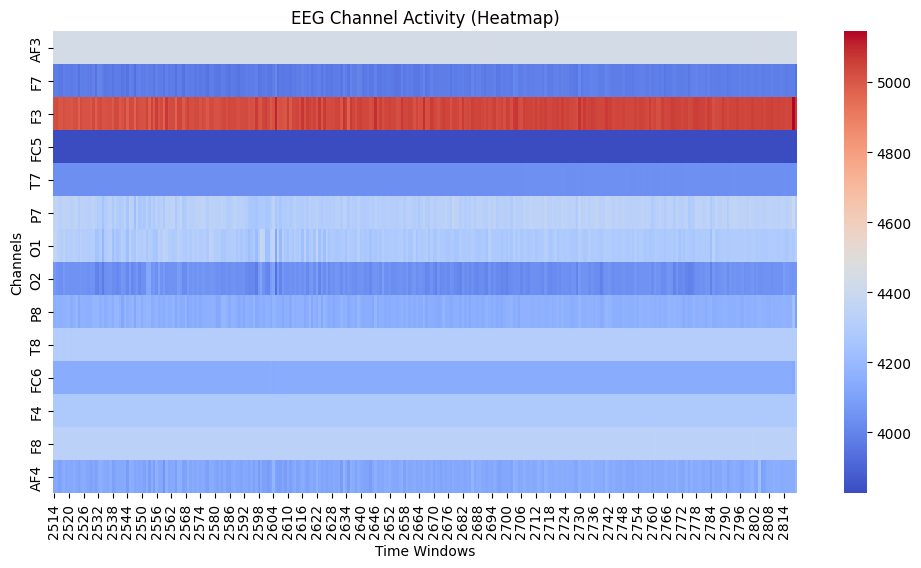

In [ ]:
aggregated_df = df.groupby(df.index // 1000).mean()

plt.figure(figsize=(12, 6))
sns.heatmap(aggregated_df.T, cmap="coolwarm", cbar=True)
plt.title("EEG Channel Activity (Heatmap)")
plt.xlabel("Time Windows")
plt.ylabel("Channels")
plt.show()

Observations

High Activity Regions:

AF3 Channel:
- Displays consistently high activity across the time windows (dominated by red hues).
- Indicates sustained neural activity in the left frontal region, possibly related to tasks involving attention, decision-making, or motor planning.

Moderate to Low Activity Regions:

Most other channels (e.g., T7, P7, P8, FC6, etc.):
- Show lower amplitudes (light blue or blue hues) throughout the time period.
- Suggests less activation in these areas or baseline brain activity.

Channel Variability:

Some channels (e.g., F3, F7, FC5):
- Show fluctuations in activity across time windows, with alternating bursts of red and blue.
- This may indicate periodic engagement or responses to stimuli/events during the recording.

Overall Trend:
There is a clear dominance of AF3 in terms of activity, while the other channels remain less active or more stable over time.

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

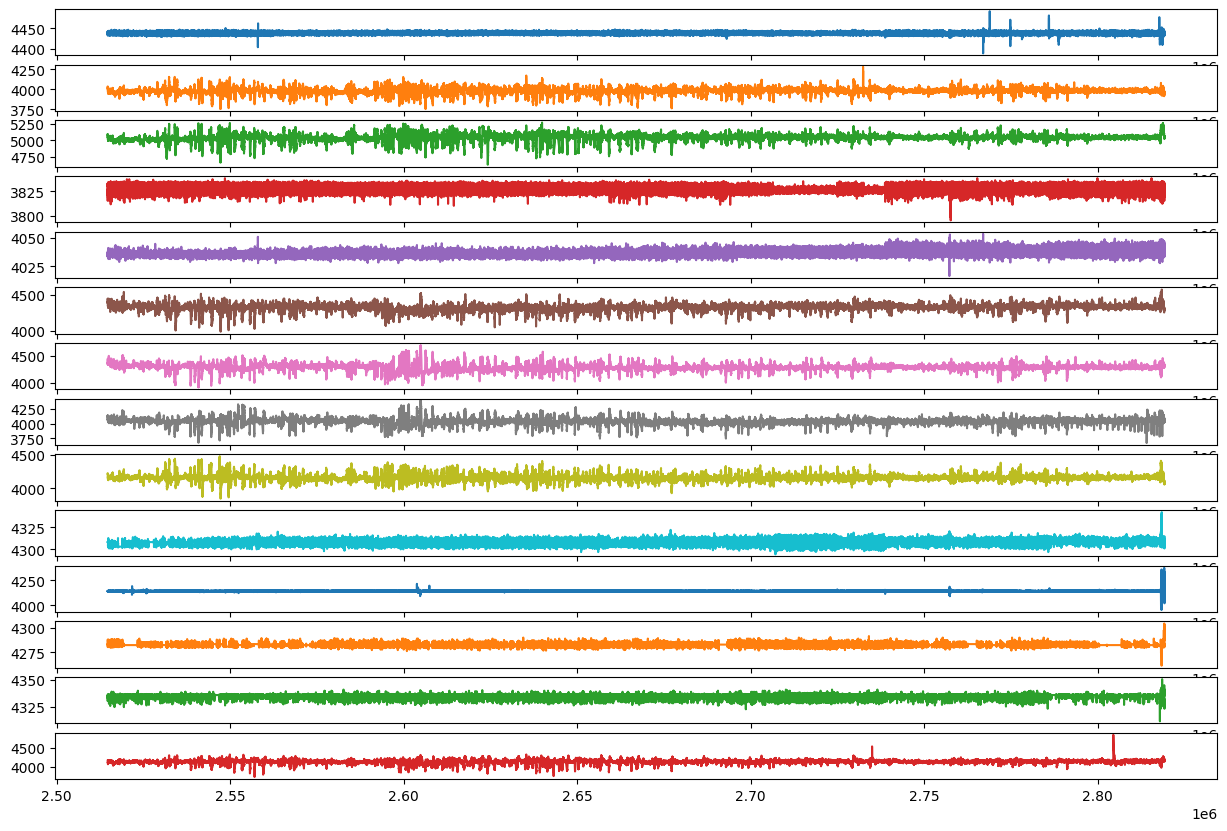

In [ ]:
df.plot(subplots=True, figsize=(15, 10), legend=False)

Observations
- Time Range (X-axis):
  - The X-axis appears to represent a consistent time range across all subplots. This indicates a common temporal reference for all series.
- Amplitude Variations (Y-axis):
  - Each subplot has a distinct amplitude range on the Y-axis, showing varying magnitudes for the observed variables.
  - Some variables remain relatively stable, while others exhibit greater fluctuation or noise.

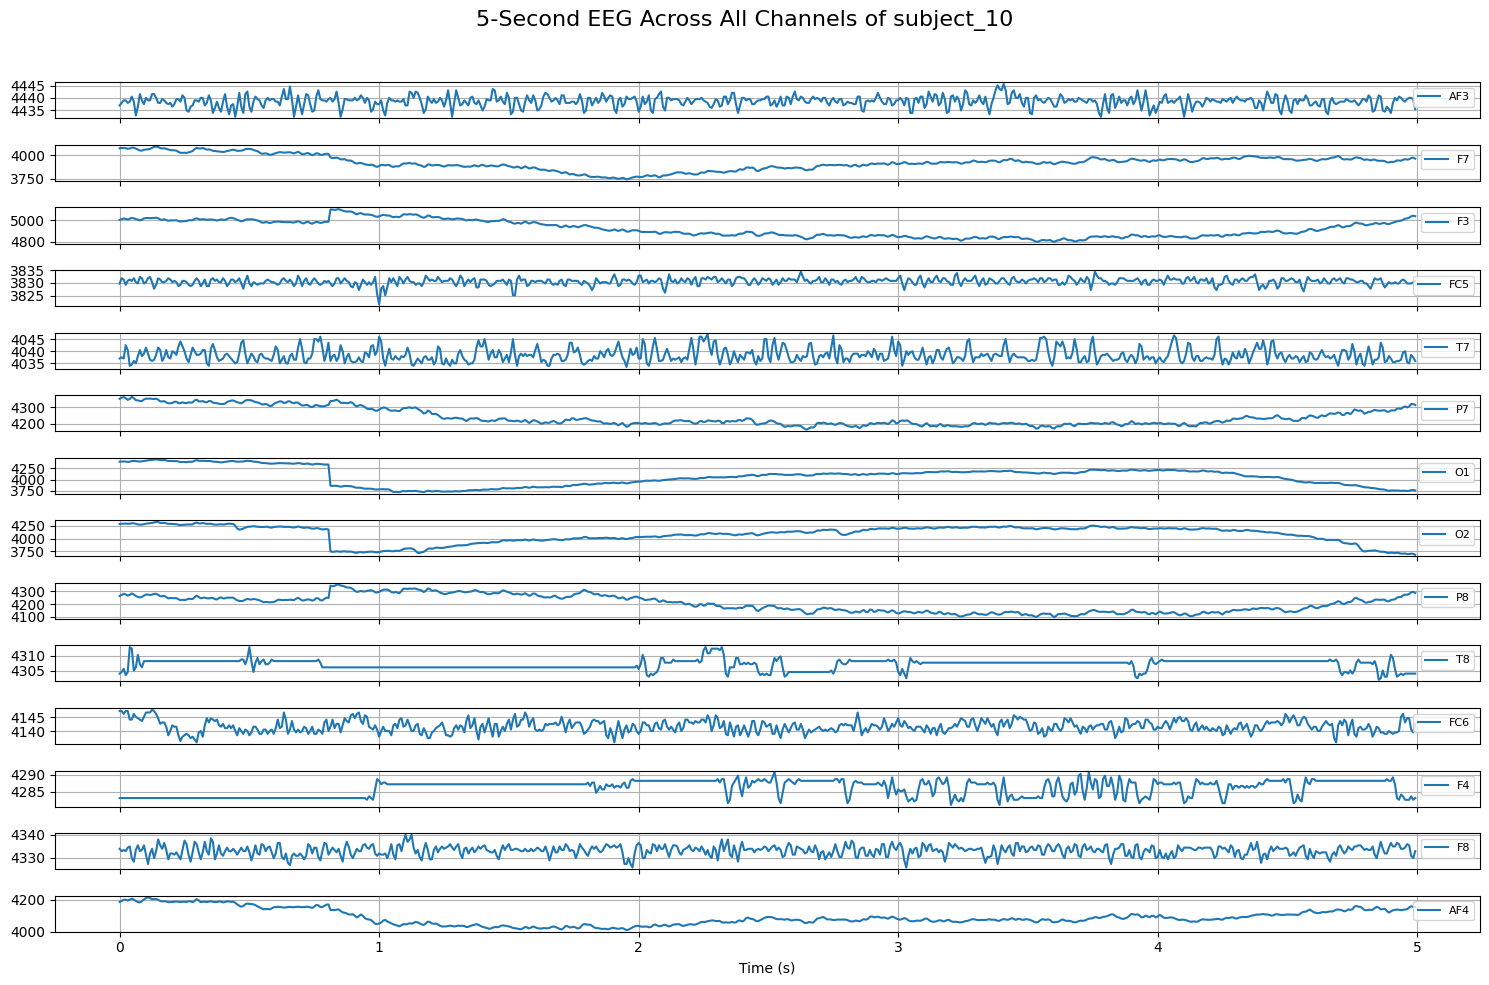

In [ ]:
sampling_rate = 128
time_window = 5
samples_per_window = sampling_rate * time_window
subject = 'subject_10'

channel_names = [col for col in df.columns]

segment = df.iloc[:samples_per_window]

fig, axes = plt.subplots(len(channel_names), 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"{time_window}-Second EEG Across All Channels of {subject}", fontsize=16)

for idx, channel in enumerate(channel_names):
    time_axis = [t / sampling_rate for t in range(len(segment))]
    axes[idx].plot(time_axis, segment[channel], label=channel)
    axes[idx].grid(True)
    axes[idx].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Observations

Signal Amplitude:
Different channels have varying ranges of signal amplitude. For instance, channels like F7 and O1 show signals with distinct and higher amplitude variability compared to others like T7 or FC6, which are more stable.

Overall Signal Trends:
Some channels, like O1 and O2, display gradual declining trends over the observed time period. In contrast, F7 and F3 seem to have consistent or slight upward trends.

Noise and Variability: Channels such as T8 and FC6 exhibit more frequent fluctuations, possibly indicating noise or high-frequency components in the signal. Channels like F4 and P7 seem to have relatively smoother signals, with fewer spikes.

Sudden Signal Jumps: In channels like P7 and O2, there are abrupt signal changes, suggesting either artifacts (e.g., movement, muscle activity) or specific neural activity patterns. These jumps can indicate external interference or transient brain activity.

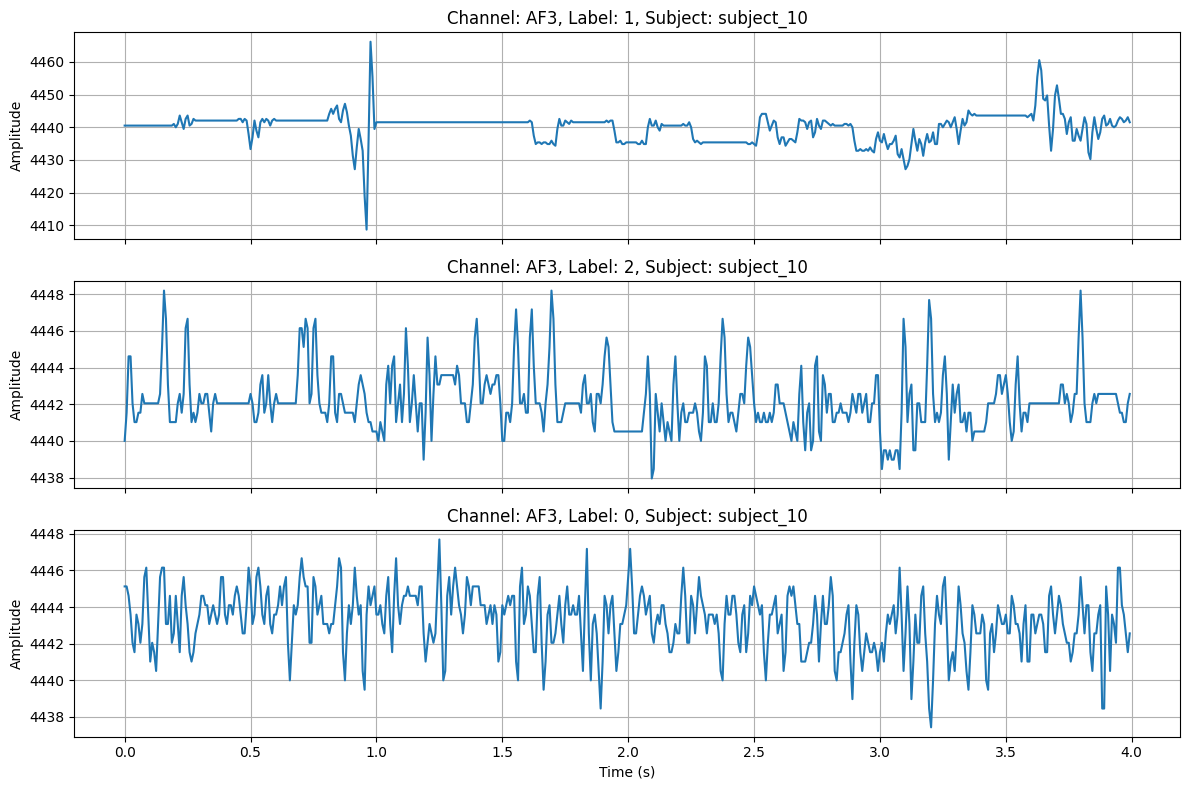

In [ ]:
sampling_rate = 128
channel_name = 'AF3'
time_window = 4
samples_per_window = sampling_rate * time_window
subject = 'subject_10'

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
labels = data['state'].unique()

for idx, label in enumerate(labels):
    label_data = data[data['state'] == label]
    segment = label_data[channel_name].iloc[:samples_per_window]
    time_axis = [t / sampling_rate for t in range(len(segment))]

    axes[idx].plot(time_axis, segment)
    axes[idx].set_title(f"Channel: {channel_name}, Label: {label}, Subject: {subject}")
    axes[idx].set_ylabel("Amplitude")
    axes[idx].grid(True)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

Plot 1 (Label: 1):

Amplitude: Ranges between 4410 and 4460, with some sharp spikes, particularly noticeable around 1.8s.

Signal Characteristics:
- The signal is largely flat or shows minimal variation in some parts (e.g., 0–1s and 2–4s), suggesting a relatively low neural activity baseline or artifact.
- However, sharp spikes and dips (e.g., at 1.8s) indicate either sudden neural events or transient artifacts.

Plot 2 (Label: 2):

Amplitude: Ranges between 4438 and 4448. The variability is moderate.

Signal Characteristics:
- The signal is more oscillatory and exhibits frequent moderate peaks and troughs, with fluctuations occurring more evenly throughout the time span.
- Compared to the first plot, this signal appears to represent a more active neural state or condition.

Plot 3 (Label: 0):

Amplitude: Similar to Plot 2, ranging between 4438 and 4448. The variability is also moderate.
Signal Characteristics:
- The oscillations in this signal are relatively more dense and continuous compared to Plot 2, with fewer flat regions.
- The signal appears noisier or contains more high-frequency components, indicating increased neural or experimental activity.

### 3. Stationary and non-stationary

A stationary time series shows a consistent pattern without any trend, seasonality, or other structural changes, while a time series with non-stationary status has statistical features that change with time Stationary means each observation is independent of the others, which means the value of a data point at one time does not depend on the value of the data point at any other time.

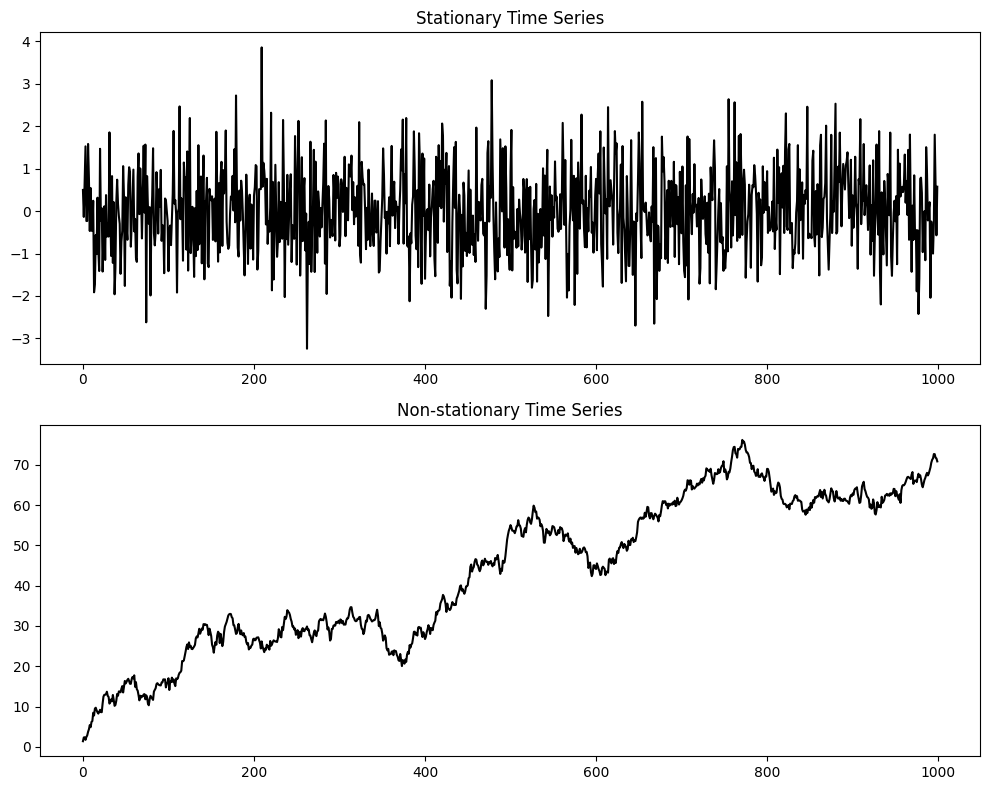

In [ ]:
np.random.seed(42)
stationary = np.random.normal(0, 1, 1000)
non_stationary = np.cumsum(np.random.normal(0, 1, 1000))
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(stationary, color='black')
plt.title("Stationary Time Series")
plt.grid(False)

plt.subplot(2, 1, 2)
plt.plot(non_stationary, color='black')
plt.title("Non-stationary Time Series")
plt.grid(False)

plt.tight_layout()
plt.show()

### 4. High frequency and low frequency

In [ ]:
def get_fft(snippet, sampling_rate=128.0):
    n = len(snippet)
    k = np.arange(n)
    T = n / sampling_rate
    frq = k / T
    frq = frq[:n // 2]

    Y = np.fft.fft(snippet) / n
    magnitude = np.abs(Y[:n // 2])
    magnitude[0] = 0

    return frq, Y, magnitude

In [ ]:
frq, Y, magnitute = get_fft(df['AF3'])

In [ ]:
sampling_rate = 128
t = np.linspace(0, 1, sampling_rate, endpoint=False)

low_freq_idx = [idx for idx, freq in enumerate(frq) if freq < 1]
high_freq_idx = [idx for idx, freq in enumerate(frq) if freq > 40]

low_freq_fft = np.zeros_like(Y, dtype=complex)
high_freq_fft = np.zeros_like(Y, dtype=complex)

low_freq_fft[low_freq_idx] = Y[low_freq_idx]
high_freq_fft[high_freq_idx] = Y[high_freq_idx]

low_freq_reconstructed = np.fft.ifft(low_freq_fft * len(t)).real
high_freq_reconstructed = np.fft.ifft(high_freq_fft * len(t)).real

KL divergence is a non-symmetric metric that measures the relative entropy or difference in information represented by two distributions. It can be thought of as measuring the distance between two data distributions showing how different the two distributions are from each other.

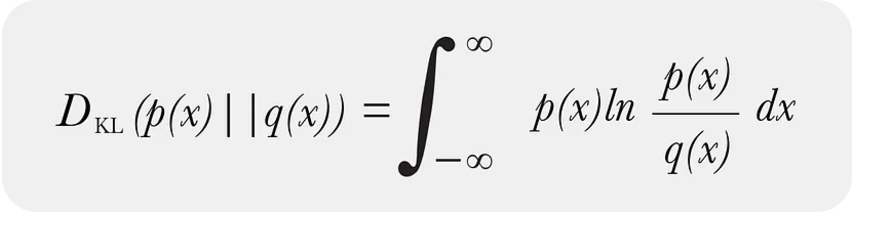

In [ ]:
def kl_divergence(signal1, signal2):
    p = np.abs(signal1) / np.sum(np.abs(signal1))
    q = np.abs(signal2) / np.sum(np.abs(signal2))

    epsilon = 1e-10
    p = np.clip(p, epsilon, None)
    q = np.clip(q, epsilon, None)

    kl_div = np.sum(rel_entr(p, q))
    return kl_div

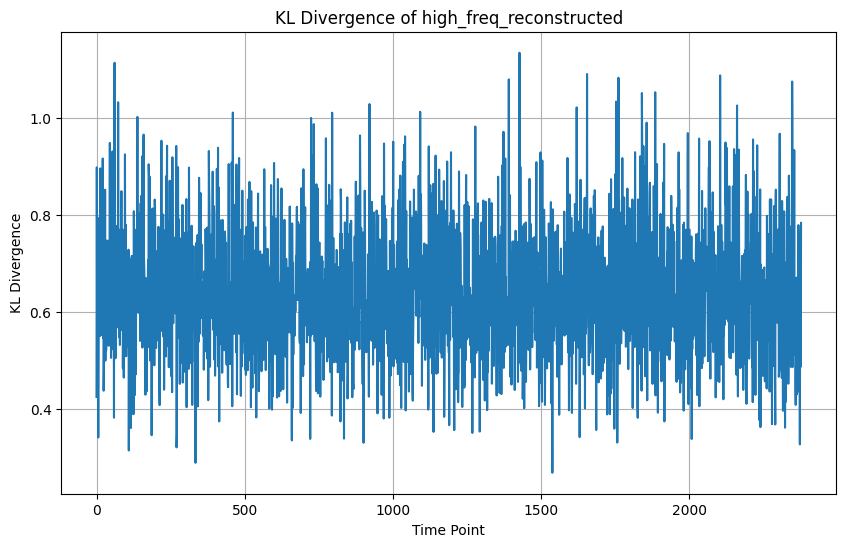

In [ ]:
kl_values = [kl_divergence(high_freq_reconstructed[:128], high_freq_reconstructed[i:i+128]) for i in range(128, len(high_freq_reconstructed) -128, 128)]
time_points = range(len(kl_values))

plt.figure(figsize=(10, 6))
plt.plot(time_points, kl_values)
plt.xlabel("Time Point")
plt.ylabel("KL Divergence")
plt.title("KL Divergence of high_freq_reconstructed")
plt.grid(True)
plt.show()

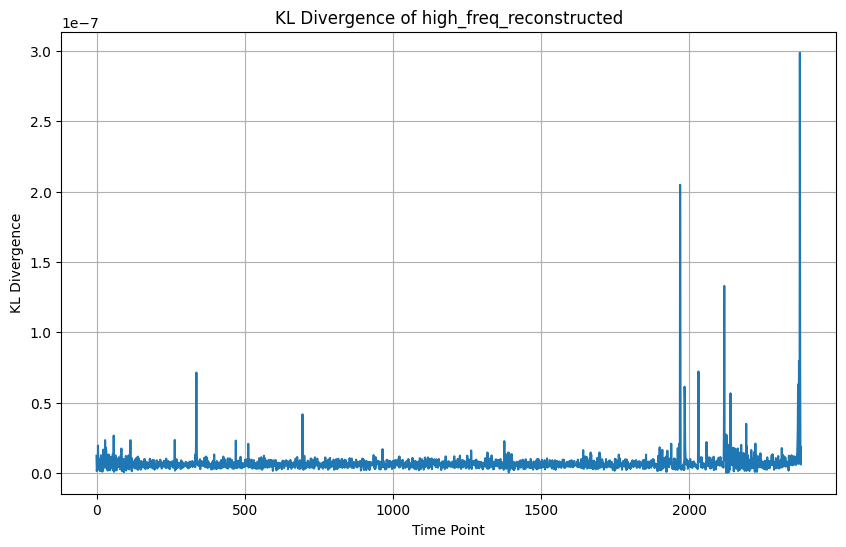

In [ ]:
kl_values = [kl_divergence(low_freq_reconstructed[:128], low_freq_reconstructed[i:i+128]) for i in range(128, len(high_freq_reconstructed) -128, 128)]
time_points = range(len(kl_values))

plt.figure(figsize=(10, 6))
plt.plot(time_points, kl_values)
plt.xlabel("Time Point")
plt.ylabel("KL Divergence")
plt.title("KL Divergence of high_freq_reconstructed")
plt.grid(True)
plt.show()

Autocorrelation measures the degree of similarity between a given time series and the lagged version of that time series over successive time periods. We calculate the correlation between two different versions Xt and Xt-k of the same time series.

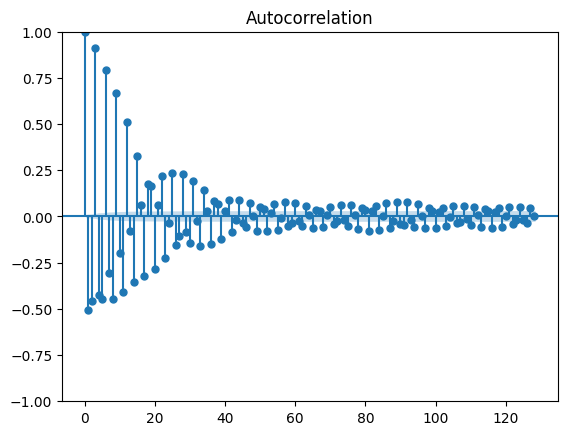

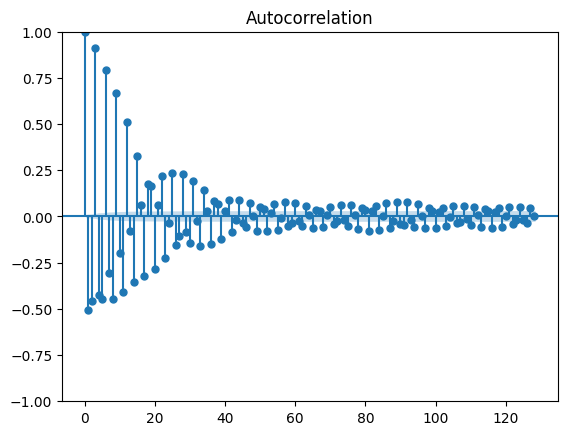

In [ ]:
plot_acf(high_freq_reconstructed[:128*60*6],lags=128)

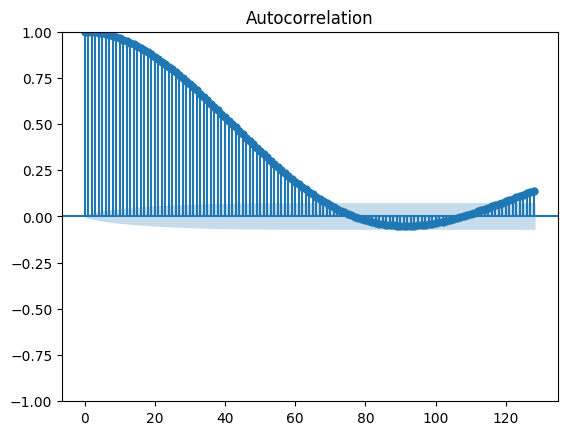

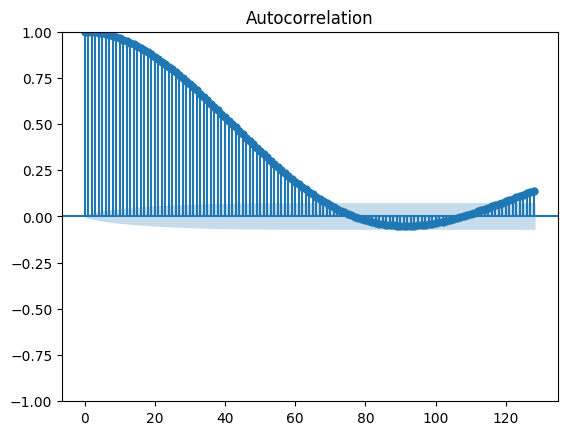

In [ ]:
plot_acf(low_freq_reconstructed[:128*60*6],lags=128)

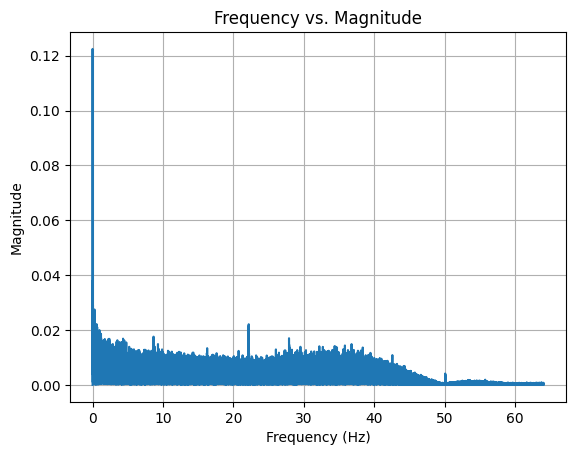

In [ ]:
plt.plot(frq, magnitute)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency vs. Magnitude')
plt.grid(True)
plt.show()

As can be seen, low frequency waves have high power.

**Conclusion:** From the KL divergence, I observe that low frequencies tend to follow the same pattern, whereas high frequencies exhibit different patterns. From the autocorrelation,based on III.3 I observe that low frequencies are non-stationary, while high frequencies are stationary. This indicates that low frequencies are highly dependent, whereas high frequencies are highly independent

### 5. Visualizing sensors' positions

Creating RawArray with float64 data, n_channels=14, n_times=304540
    Range : 0 ... 304539 =      0.000 ...  2379.211 secs
Ready.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


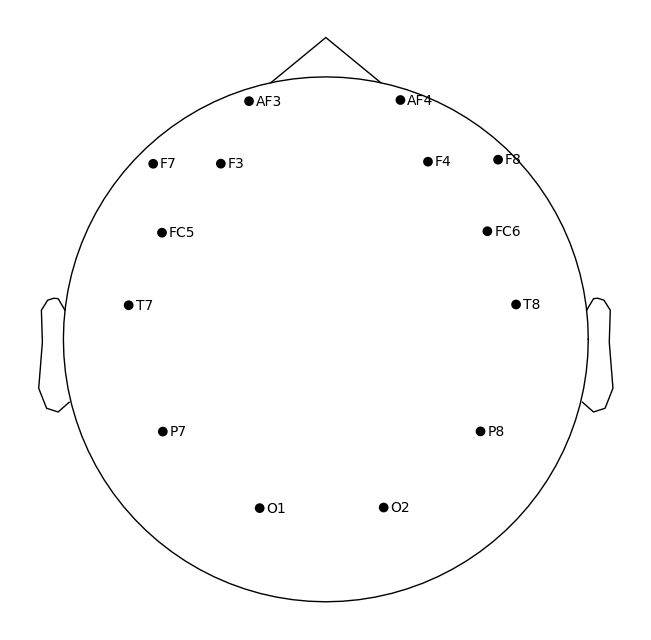

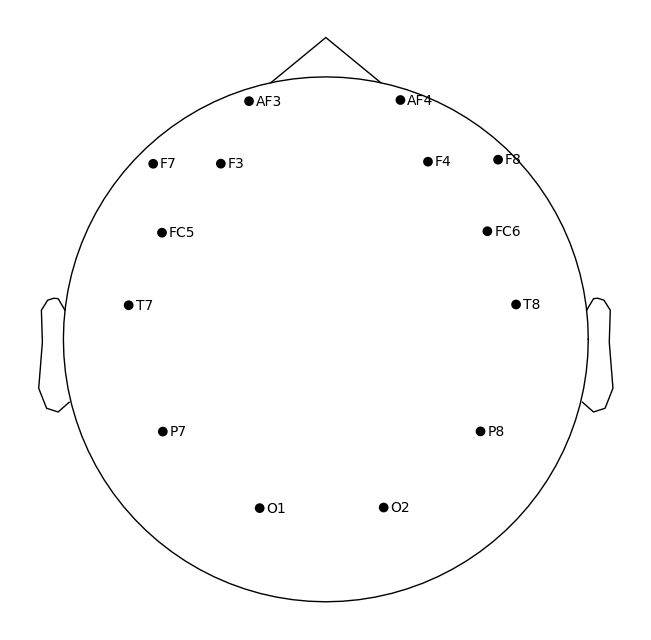

In [ ]:
n_channels = 14
n_samples = len(df)
sfreq = 128
raw = pandas_to_mne(df, sfreq)
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)
raw.pick_types(eeg=True)

raw.plot_sensors(show_names=True)

**Conclusion:** AF4 and AF3 are the channels located near the eyes.

### 6. Find bad channels

A correlation window is considered “bad” for a channel if its maximum correlation with another channel is below the provided correlation threshold (default: 0.4)

In [ ]:
bad_channels=[]
sfreq=128
for subject in list(set(data['subject'])):
    df = data[data['subject'] == subject]
    columns_to_drop = ['subject', 'state']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)
    raw = pandas_to_mne(df, sfreq)
    noisy_channels_detector = NoisyChannels(raw, do_detrend=True, random_state=42, matlab_strict=False)

    noisy_channels_detector.find_bad_by_correlation()

    bad_channels.append(noisy_channels_detector.get_bads())

Creating RawArray with float64 data, n_channels=14, n_times=259480
    Range : 0 ... 259479 =      0.000 ...  2027.180 secs
Ready.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 423 samples (3.305 s)

Creating RawArray with float64 data, n_channels=14, n_times=280424
    Range : 0 ... 280423 =      0.000 ...  2190.805 secs
Ready.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwi

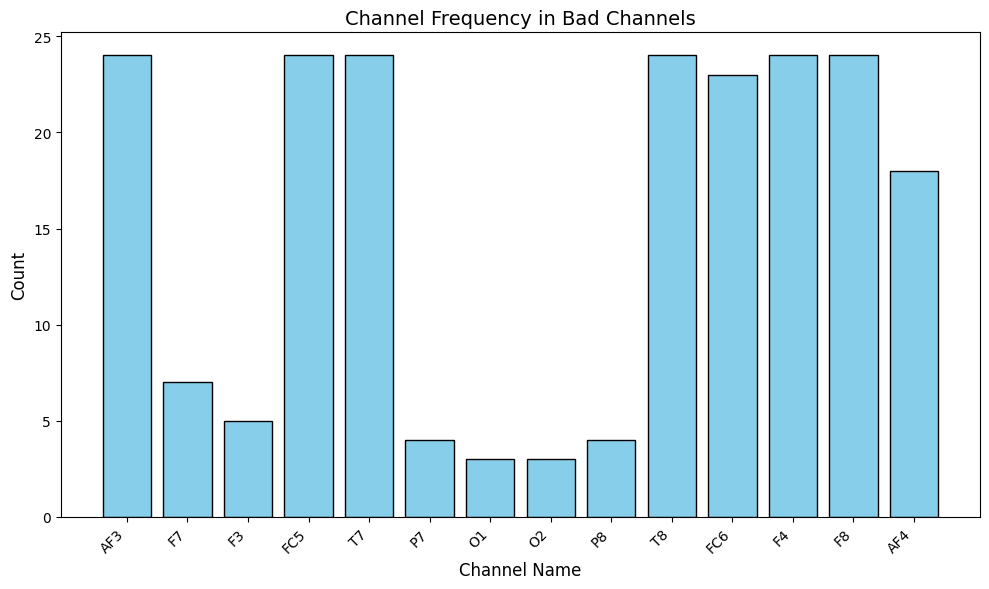

In [ ]:
flat_list = list(chain.from_iterable(bad_channels))
channel_name = df.columns.to_list()

channel_counts = {channel: flat_list.count(channel) for channel in channel_name}

channels = list(channel_counts.keys())
counts = list(channel_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(channels, counts, color='skyblue', edgecolor='black')
plt.xlabel('Channel Name', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Channel Frequency in Bad Channels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Conclusion:** The AF4, AF3, FC5, T7, T8, FC6, F4, AF4, and F8 channels are the most affected. In contrast, the O1 and O2 channels are the best because their locations are far from the eyes and near the top of the head. As mentioned in Section III.5, AF4 and AF3 are closest to the eyes. For this reason, AF4 and AF3 are highly susceptible to artifacts caused by blinks and eye movements.  


## V. Preprocessing with ICA

Stereotyped Artifacts

- Stereotyped artifacts are repeated, predictable noise patterns, such as line noise caused by electrical interference or biological artifacts like eye movements and muscle activity. These artifacts are systematic and can often be addressed using techniques such as filtering. For example, eye movements and blinks produce characteristic signals that are consistent over time, making them easier to identify and mitigate.

- Non-Stereotyped Artifacts
Non-stereotyped artifacts are irregular, unpredictable patterns, often resulting from head movements, electrode shifts, or other sudden actions. These artifacts introduce unique noise into the EEG data, complicating processes like Independent Component Analysis (ICA). For instance, if a subject scratches their EEG cap for several seconds, the resulting signal includes a series of varying scalp maps due to channel and wire movements. Such non-stereotyped or paroxysmal noise requires manual removal before performing ICA decomposition.

### 1. Filter

Based on the ICA assumptions:

1. The source signals are statistically independent of each other.
2. The values in each source signal follow a non-Gaussian distribution.

The first condition does not need to be addressed, as the raw data inherently exhibits non-Gaussian distribution. For the second condition, based on the III.3 view of high-frequency and low-frequency waves, I need to filter out low frequencies (<1 Hz) due to their non-stationary nature (dependency), which might cause issues for ICA. Similarly, I filter out high frequencies (>40 Hz) because of complicating ICA.

In [ ]:
montage = mne.channels.make_standard_montage('standard_1020')  # Adjust as needed
raw.set_montage(montage)
raw.pick_types(eeg=True)
raw_ica = raw.copy().filter(1, 40, fir_design='firwin', picks=['eeg'],verbose=False)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


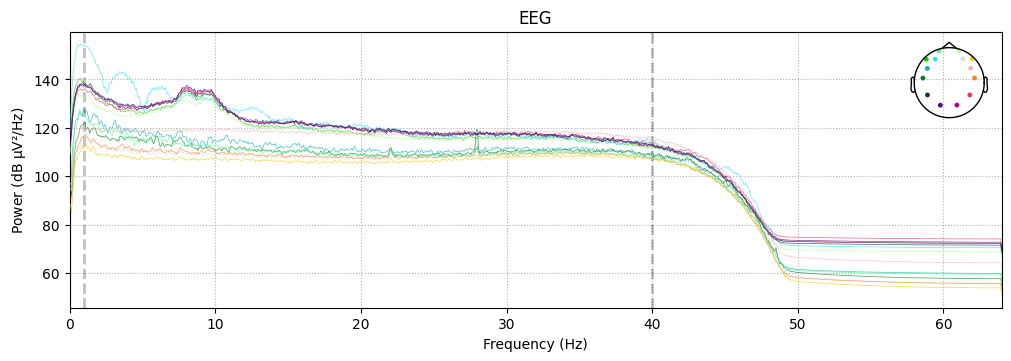

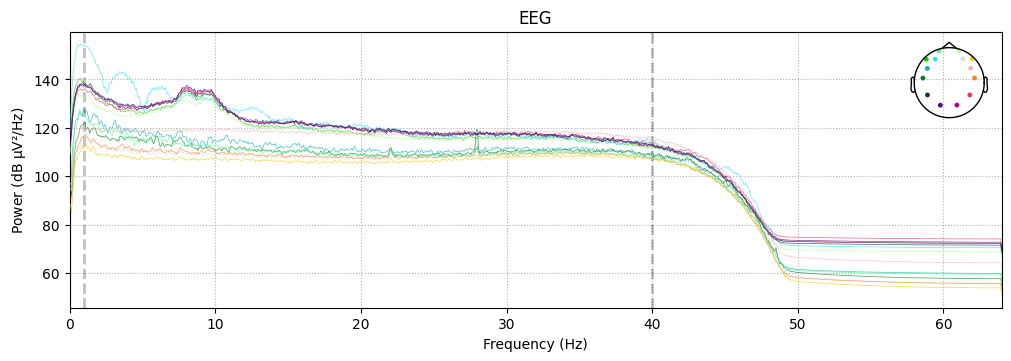

In [ ]:
raw_ica.compute_psd().plot()

However we not only filter noise ? The reason why will be shown below:

#### a. Aliasing

Aliasing occurs when a signal is sampled at a rate insufficient to capture its true frequency, resulting in the signal being misrepresented as a lower-frequency oscillation. Aliasing can compromise the accuracy of EEG data analysis, as high-frequency noise can appear as meaningful lower-frequency signals, potentially leading to incorrect interpretations. To prevent aliasing, EEG systems must be designed with an appropriate sampling rate—typically at least twice the highest frequency of interest, as specified by the Nyquist theorem—and employ filters to eliminate frequencies above this range.

For example, in a certain situation, the EEG was recorded with a sampling rate of 500 Hz, meaning a measurement from each electrode was obtained every 2 milliseconds. This sampling rate is sufficient to detect an EEG signal oscillating at 30 Hz. Over the duration of each cycle of the 30 Hz oscillation (e.g., from one peak to the next), which lasts 1/30th of a second, the system captures approximately 500/30 ≈ 17500/30 ≈ 17 measurements of the waveform. These samples are adequate to accurately represent the shape of the oscillating sine wave.

Now, consider a scenario where an electromagnetic noise signal in the environment oscillates at 1700 Hz. This noise signal would complete 1700 oscillations in one second, but the EEG amplifier, sampling only 500 times per second, cannot detect such a high-frequency signal. In this case, 3.4 oscillations of the noise waveform occur between each sample recorded by the EEG amplifier. Because 1700 Hz is not an even multiple of 500 Hz, each sample will correspond to a different phase of the 1700 Hz oscillation—sometimes capturing the peak, sometimes the trough, and other times intermediate points. When these sampled points are connected to form the measured signal, the result will appear as a much lower-frequency oscillation than the actual 1700 Hz noise.


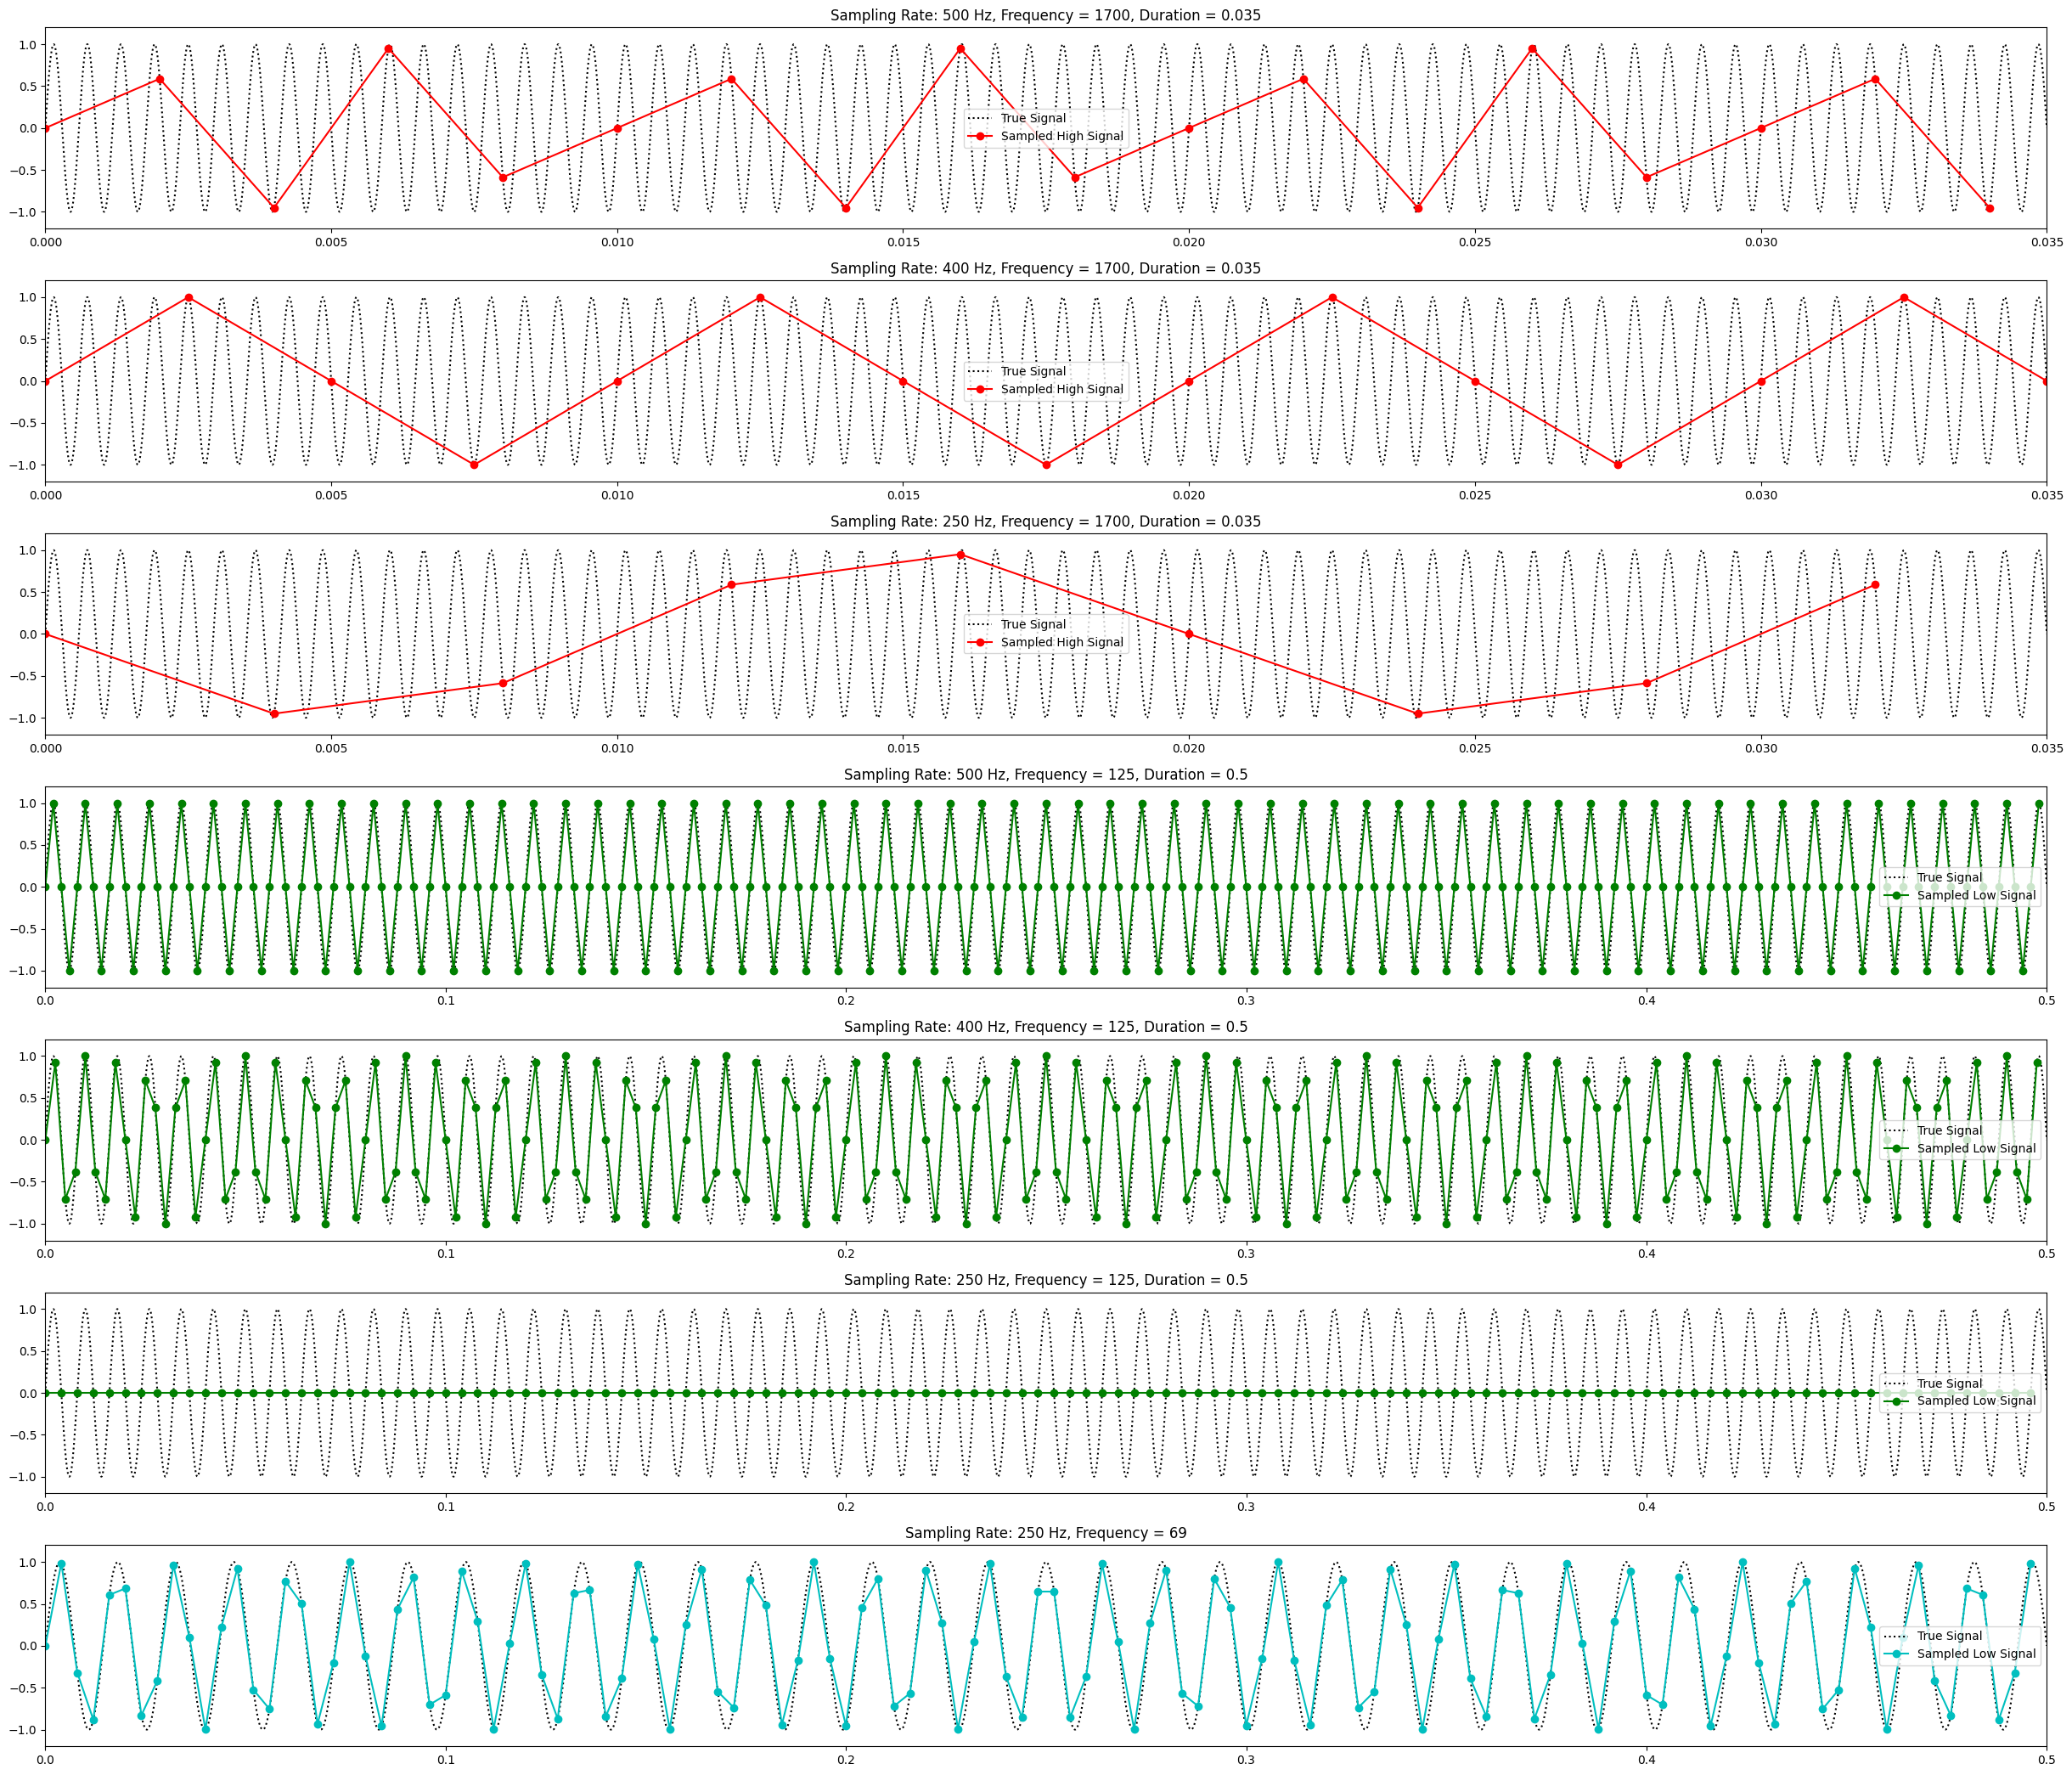

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

high_frequency = 1700
low_frequency_1 = 125
low_frequency_2 = random.sample(range(25, 125), 1)[0]
sampling_rates = [500, 400, 250]
duration = 0.035

t = np.linspace(0, duration, 10000)
high_signal = np.sin(2 * np.pi * high_frequency * t)


fig, axes = plt.subplots(7, 1, figsize=(24.5, 21))
axes = axes.flatten()


for i, sr in enumerate(sampling_rates):
    sample_times = np.arange(0, duration, 1 / sr)
    sampled_high_signal = np.sin(2 * np.pi * high_frequency * sample_times)

    axes[i].plot(t, high_signal, 'k:', label="True Signal")
    axes[i].plot(sample_times, sampled_high_signal, 'ro-', label="Sampled High Signal")
    axes[i].set_title(f"Sampling Rate: {sr} Hz, Frequency = {high_frequency}, Duration = {duration}")
    axes[i].set_xlim(0, duration)
    axes[i].set_ylim(-1.2, 1.2)

    axes[i].legend()


duration = 0.5
t = np.linspace(0, duration, 10000)
low_signal_1 = np.sin(2 * np.pi * low_frequency_1 * t)
low_signal_2 = np.sin(2 * np.pi * low_frequency_2 * t)

for i, sr in enumerate(sampling_rates, len(sampling_rates)):
    sample_times = np.arange(0, duration, 1 / sr)
    sampled_low_signal = np.sin(2 * np.pi * low_frequency_1 * sample_times)

    axes[i].plot(t, low_signal_1, 'k:', label="True Signal")
    axes[i].plot(sample_times, sampled_low_signal, 'go-', label="Sampled Low Signal")
    axes[i].set_title(f"Sampling Rate: {sr} Hz, Frequency = {low_frequency_1}, Duration = {duration}")
    axes[i].set_xlim(0, duration)
    axes[i].set_ylim(-1.2, 1.2)

    axes[i].legend()


sample_times = np.arange(0, duration, 1 / 250)
sampled_low_signal = np.sin(2 * np.pi * low_frequency_2 * sample_times)

axes[6].plot(t, low_signal_2, 'k:', label="True Signal")
axes[6].plot(sample_times, sampled_low_signal, 'co-', label="Sampled Low Signal")
axes[6].set_title(f"Sampling Rate: {250} Hz, Frequency = {low_frequency_2}")
axes[6].set_xlim(0, duration)
axes[6].set_ylim(-1.2, 1.2)

axes[6].legend()

plt.tight_layout()
plt.show()

Dominant Frequency: 68.48 Hz
True Frequency: 69.00 Hz
Dominant Amplitude: 1.08


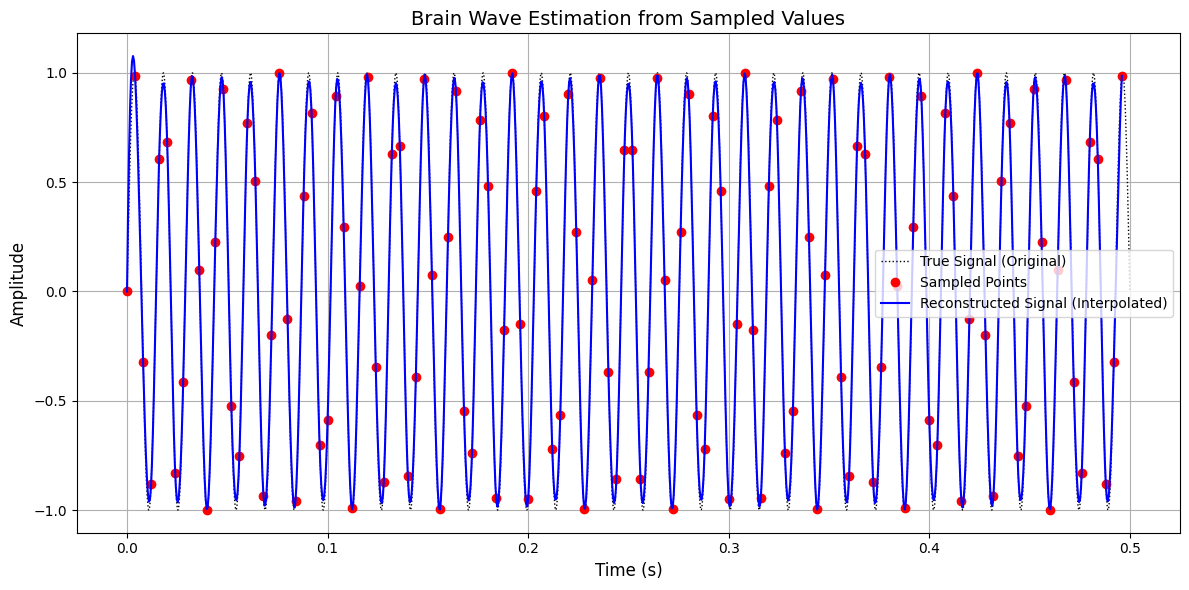

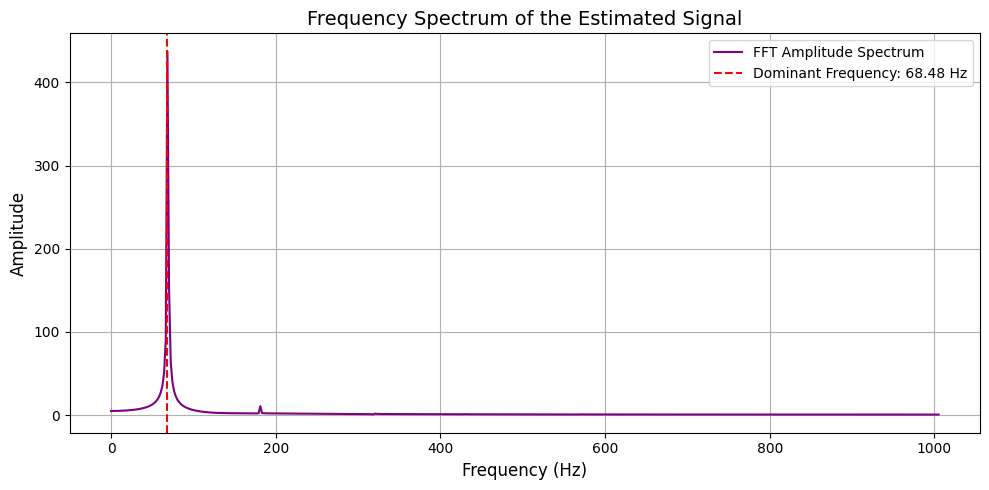

In [ ]:
# Parameters for low-frequency signal
sampling_rate = 250  # Sampling rate (Hz)
duration = 0.5  # Duration of the signal (seconds)

# Generate the true signal (high-resolution time vector)
t_true = np.linspace(0, duration, 10000)  # High-resolution time vector
low_signal_2 = np.sin(2 * np.pi * low_frequency_2 * t_true)  # True low-frequency signal

# Sample the signal
sample_times = np.arange(0, duration, 1 / sampling_rate)  # Sampled time points
sampled_signal = np.sin(2 * np.pi * low_frequency_2 * sample_times)  # Sampled signal values

# Reconstruct the signal using interpolation
interp_function = interp1d(sample_times, sampled_signal, kind='cubic', bounds_error=False, fill_value="extrapolate")
# Generate t_estimated within the bounds of sample_times
t_estimated = np.linspace(sample_times[0], sample_times[-1], 1000)  # Ensure t_estimated is within bounds
estimated_signal = interp_function(t_estimated)  # Reconstructed signal

# Estimate Frequency and Amplitude using FFT
n = len(t_estimated)  # Number of points in the estimated signal
fft_result = np.fft.fft(estimated_signal)  # Perform FFT
frequencies = np.fft.fftfreq(n, d=(t_estimated[1] - t_estimated[0]))  # Corresponding frequencies

# Take only positive frequencies and amplitudes
positive_freqs = frequencies[:n // 2]
fft_amplitudes = np.abs(fft_result[:n // 2])

# Find the dominant frequency and amplitude
dominant_freq_idx = np.argmax(fft_amplitudes)
dominant_frequency = positive_freqs[dominant_freq_idx]
dominant_amplitude = np.max(estimated_signal)

# Print the results
print(f"Dominant Frequency: {dominant_frequency:.2f} Hz")
print(f"True Frequency: {low_frequency_2:.2f} Hz")
print(f"Dominant Amplitude: {dominant_amplitude:.2f}")

# Plot the original, sampled, and reconstructed signals
plt.figure(figsize=(12, 6))
plt.plot(t_true, low_signal_2, 'k:', label='True Signal (Original)', linewidth=1)  # Original signal
plt.plot(sample_times, sampled_signal, 'ro', label='Sampled Points')  # Sampled points
plt.plot(t_estimated, estimated_signal, 'b-', label='Reconstructed Signal (Interpolated)', linewidth=1.5)  # Reconstructed signal

# Add labels and title
plt.title('Brain Wave Estimation from Sampled Values', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the FFT result
plt.figure(figsize=(10, 5))
plt.plot(positive_freqs, fft_amplitudes, color='purple', label='FFT Amplitude Spectrum')
plt.axvline(dominant_frequency, color='red', linestyle='--', label=f'Dominant Frequency: {dominant_frequency:.2f} Hz')
plt.title('Frequency Spectrum of the Estimated Signal', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


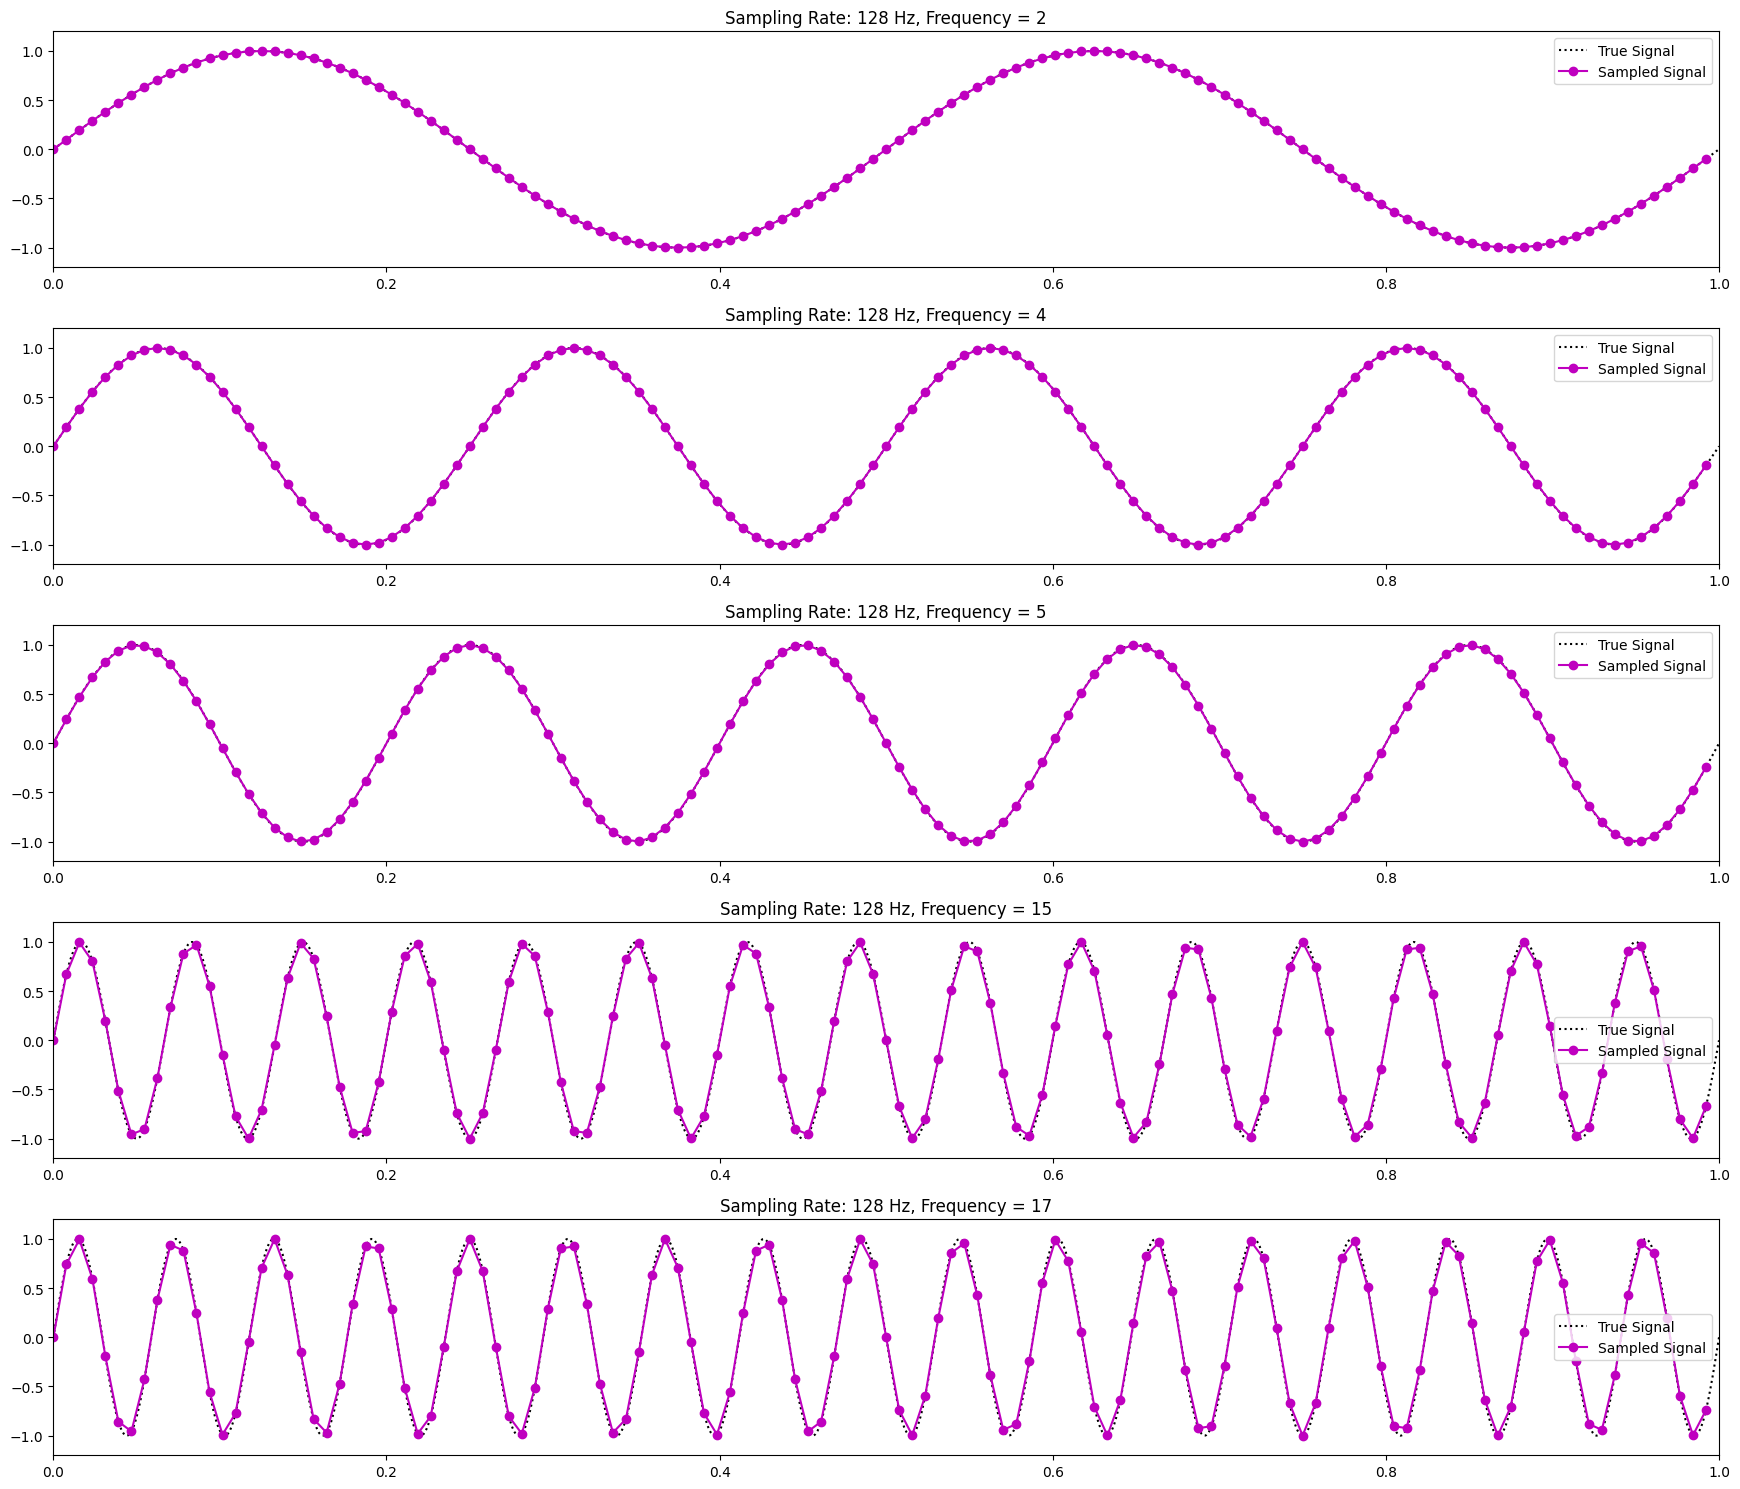

In [ ]:
# Parameters
frequencies = random.sample(range(1, 31), 5)  # Frequencies (Hz) of 5 signals whose values
                                            # are randomly generated the range [1, 30]
frequencies.sort()
sampling_rate = 128  # Sampling rates to simulate aliasing
duration = 1  # Duration of the signal (seconds)

t = np.linspace(0, duration, 10000)  # High-resolution time vector for the true signal
# Generate sine waves whose frequency are randomly generated the range [1, 30]
signal = []
for frequency in frequencies:
    signal_i = np.sin(2 * np.pi * frequency * t)
    signal.append(signal_i)

# Plotting the aliasing examples
fig, axes = plt.subplots(5, 1, figsize=(17.5, 15))
axes = axes.flatten()

# Plotting 5 random frequencies whose values vary between 1 and 30
for i, frequency in enumerate(frequencies):
    sample_times = np.arange(0, duration, 1 / sampling_rate)  # Sampled time points
    sampled_signal = np.sin(2 * np.pi * frequency * sample_times)  # Sampled signal

    axes[i].plot(t, signal[i], 'k:', label="True Signal")  # True signal (dotted black line)
    axes[i].plot(sample_times, sampled_signal, 'mo-', label="Sampled Signal")  # Sampled points (red)
    axes[i].set_title(f"Sampling Rate: {sampling_rate} Hz, Frequency = {frequency}")
    axes[i].set_xlim(0, duration)
    axes[i].set_ylim(-1.2, 1.2)

    axes[i].legend()

plt.tight_layout()
plt.show()

**Conclusion:** Filter is not enough

### 2. Segmentation

Extracting data epochs reduces the number of samples, and ICA component quality is usually higher when more data is present. In our pre-processing step,
the sampled raw EEG signal is divided into epochs of size N.
Very short segments (< 1 s) may not represent some slow
artifacts properly (e.g. ocular or movement artifacts) whereas
in very large windows (e.g. > 5 s), the stationary assumption
of EEG may be no longer valid and there is a high chance that
clean EEG segments will be distorted by the artifact removal
pr.cedure

In [ ]:
import mne

tstep = 5.0

events_ica = mne.make_fixed_length_events(raw_ica, duration=tstep)

epochs_ica = mne.Epochs(raw_ica, events_ica,
                        tmin=0.0, tmax=tstep,
                        baseline=None,
                        preload=True)

Not setting metadata
635 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 635 events and 641 original time points ...
0 bad epochs dropped


### 3. Initial Cleaning for ICA

As I mention, in this step I try to exclude Non-stereotyped artifacts.

AutoReject, as the name implies, is an automated and data-driven way of determining a threshold to distinguish between “noisy” and “clean” channels and epochs in the data. It is an iterative process that repeatedly takes sub-samples of the entire data set, and computes the variance of each channel and epoch. It then computes a threshold for each channel and epoch, based on the distribution of variances across the entire data set. It then rejects any channels or epochs that exceed the threshold.

In [ ]:
ar = AutoReject(n_interpolate=[1, 2, 4],
                random_state=42,
                picks=mne.pick_types(epochs_ica.info,
                                     eeg=True,
                                     eog=False
                                    ),
                n_jobs=4,
                verbose=False
                )

ar.fit(epochs_ica)

reject_log = ar.get_reject_log(epochs_ica)

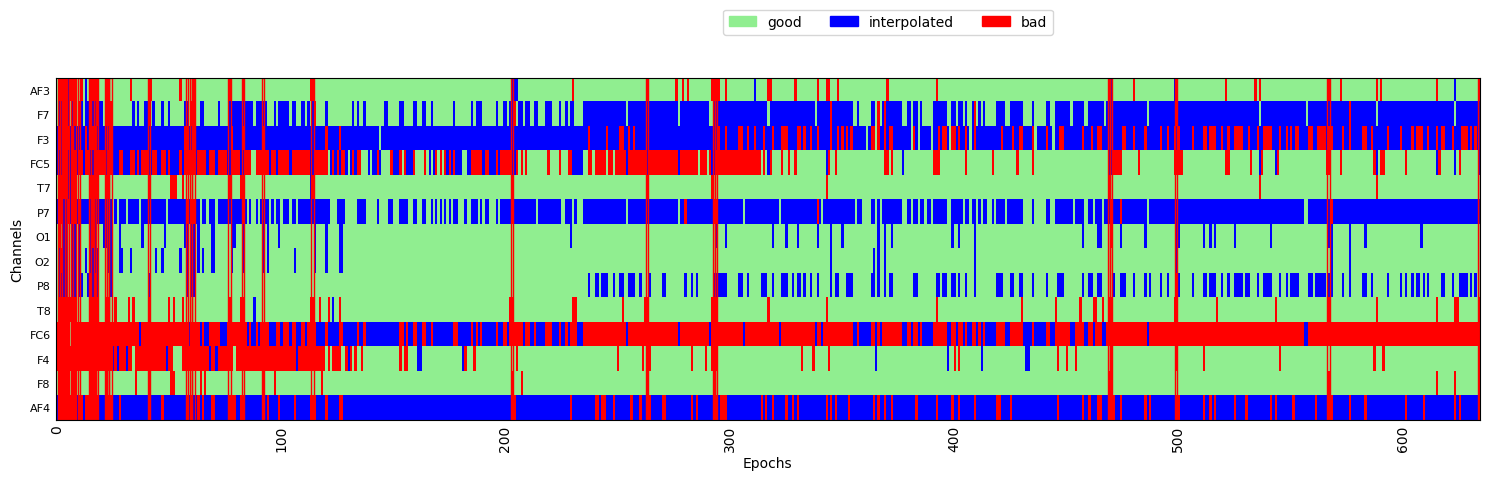

In [ ]:
fig, ax = plt.subplots(figsize=[15, 5])
reject_log.plot('horizontal', ax=ax, aspect='auto')
plt.show()

Green areas represent “good” data, while the red vertical lines indicate epochs that AutoReject has marked as “bad.” The blue lines signify specific channels marked as “bad” in epochs where most of the channels were considered “good.” In such cases, AutoReject interpolates the data from the bad channels based on the surrounding channels rather than rejecting the entire epoch due to one or a few bad channels. This approach is justified because eye movements, which can occur over short periods, are more common, whereas non-stereotyped artifacts are less likely to occur within such a brief timeframe. Furthermore, at this stage, I aim to remove non-stereotyped artifacts and, therefore, prefer to retain the blue epochs.

###  4. Independent Component Analysis (ICA)

What is Independent Component Analysis?

Independent Component Analysis (ICA) is a statistical and computational technique commonly used in machine learning to separate a multivariate signal into its independent, non-Gaussian components. The primary goal of ICA is to apply a linear transformation to the data such that the resulting components are as statistically independent as possible.  

The core of ICA is based on the principle of statistical independence, which is used to identify individual components within mixed signals that are independent of each other.  

**Statistical Independence Concept:**  
In probability theory, statistical independence between two random variables, X and Y, implies that their joint probability distribution is equal to the product of their individual probability distributions. Mathematically, (P(X, Y) = P(X)P(Y)\). This means that knowing the outcome of one variable provides no information about the probability of the other variable’s outcome.  

By leveraging this concept, ICA separates mixed signals into statistically independent components, enabling its application in various fields such as signal processing, neuroscience, and data analysis.

ICA in EEG

ICA is very good at capturing features of the data that explain the most variance. Blinks and eye movements are well-captured by ICA because they are so much larger than EEG, and so they contain a lot of the variance in the EEG recordings.  ICA assumes the data is stationary, meaning statistical properties (like mean and variance) do not change over time.
Low-frequency components often introduce non-stationary trends (e.g., baseline drifts or shifts in electrode potential).
Removing these trends helps the data better meet ICA’s theoretical assumptions.


Excluding bad epochs identified beforehand, the ICA decomposition focuses on cleaner data, leading to more reliable identification of artifact-related independent components (e.g., those corresponding to eye blinks or muscle artifacts).

In [ ]:
random_state = 42
ica_n_components = .99


ica = mne.preprocessing.ICA(n_components=ica_n_components,
                            random_state=random_state,
                            )
ica.fit(epochs_ica[~reject_log.bad_epochs], decim=3)

Fitting ICA to data using 14 channels (please be patient, this may take a while)
Selecting by explained variance: 10 components
Fitting ICA took 4.1s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,31 iterations on epochs (129042 samples)
ICA components,10
Available PCA components,14
Channel types,eeg
ICA components marked for exclusion,—


 Voltage maps use colors to represent the polarity and intensity of electrical signals:

- Blue: Indicates negative polarity.
- Red: Indicates positive polarity.

Color Intensity: Stronger signals are represented by more intense colors. Equipotential Lines: These lines show steps in voltage levels, helping to delineate regions of similar potentials.

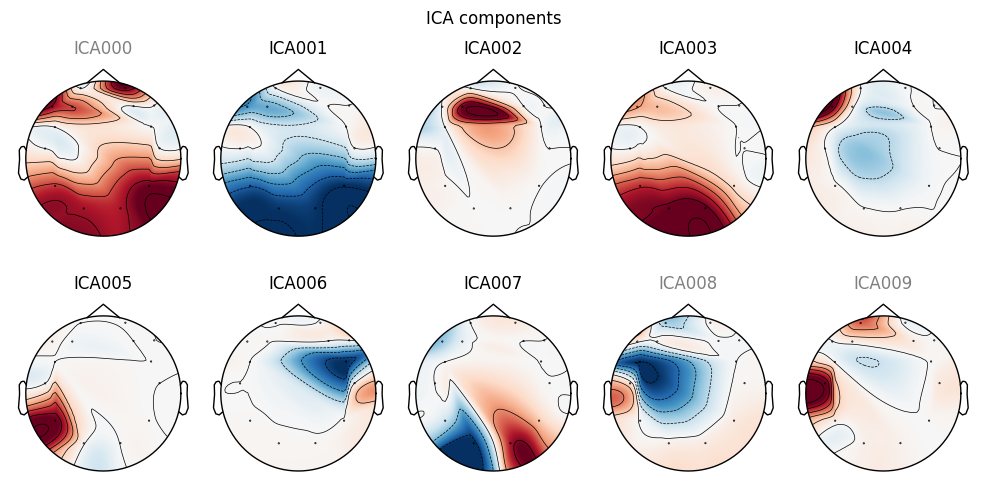

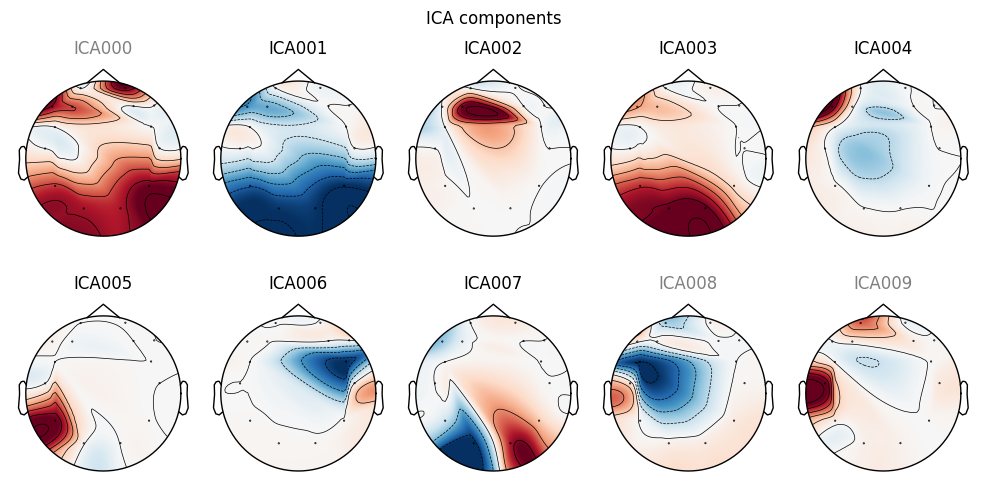

In [ ]:
ica.plot_components()

We can observe that ICA000 and ICA009 exhibit high voltage levels near the eye region, suggesting they might be influenced by eye movements.

### 5. Find threshold to remove noisy components

find_bads_eog() also takes a threshold kwarg, which is the correlation threshold that will be used to identify ICs that are likely ocular artifacts. We use a while loop to iterate over a range of threshold values, starting from a relatively high value of 3.5 and stepping down in increments of 0.1, until at least 2 ICs are identified. Since we expect both blinks and horizontal eye movements in the data, we expect at least 2 ICs to be identified as artifacts, and these should be the two that have the highest correlation values with the channels around the eyes. This algorithm is not perfect; it is possible that it will identify other ICs as artifacts, so it is important to cross-reference .

Based on Section III.6, I chose AF3 and AF4 because they are strongly affected by eye movements.

In [ ]:
ica.exclude = []
num_excl = 0
max_ic = 2
z_thresh = 3.5
z_step = .05

while num_excl < max_ic:
    eog_indices, eog_scores = ica.find_bads_eog(epochs_ica,
                                                ch_name=['AF3','AF4'],
                                                threshold=z_thresh
                                                )
    num_excl = len(eog_indices)
    z_thresh -= z_step


ica.exclude = eog_indices

print('Final z threshold = ' + str(round(z_thresh, 2)))

Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Using EOG channels: AF3, AF4
Final z threshold = 2.45


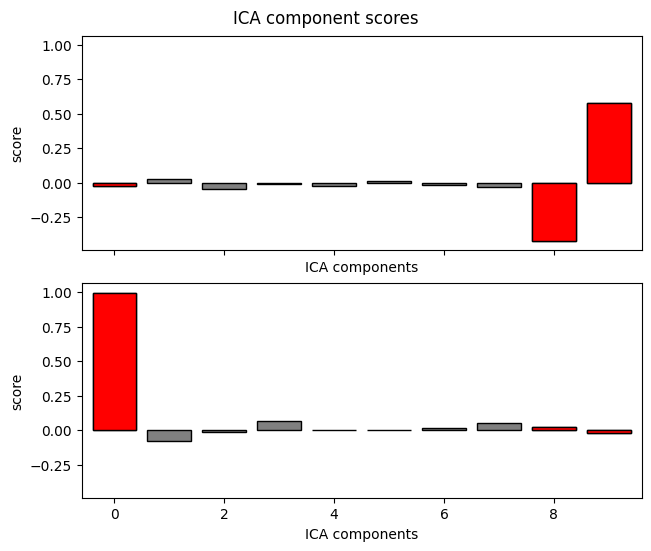

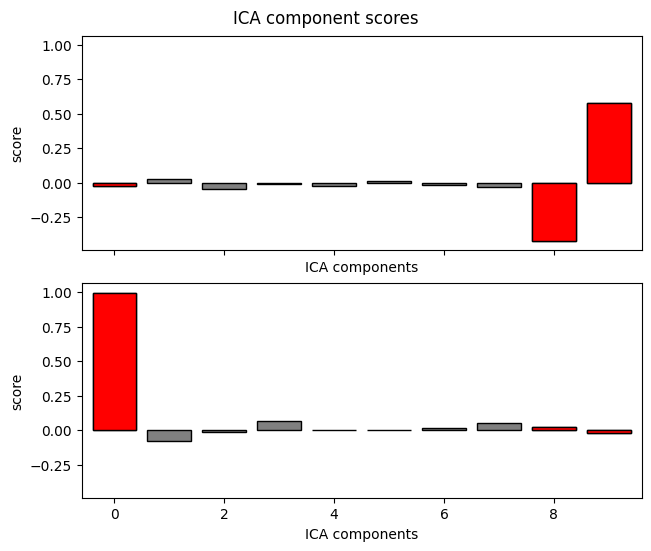

In [ ]:
ica.plot_scores(eog_scores)

ICA008,ICA000 and ICA009 had the highest correlation values, and were rejected

In [ ]:
epochs_postica = ica.apply(epochs_ica.copy())

Applying ICA to Epochs instance
    Transforming to ICA space (10 components)
    Zeroing out 3 ICA components
    Projecting back using 14 PCA components


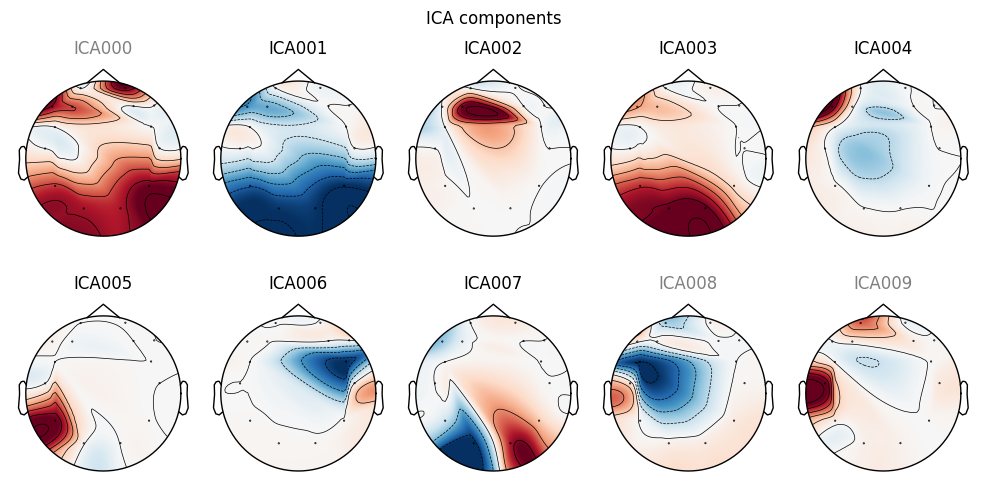

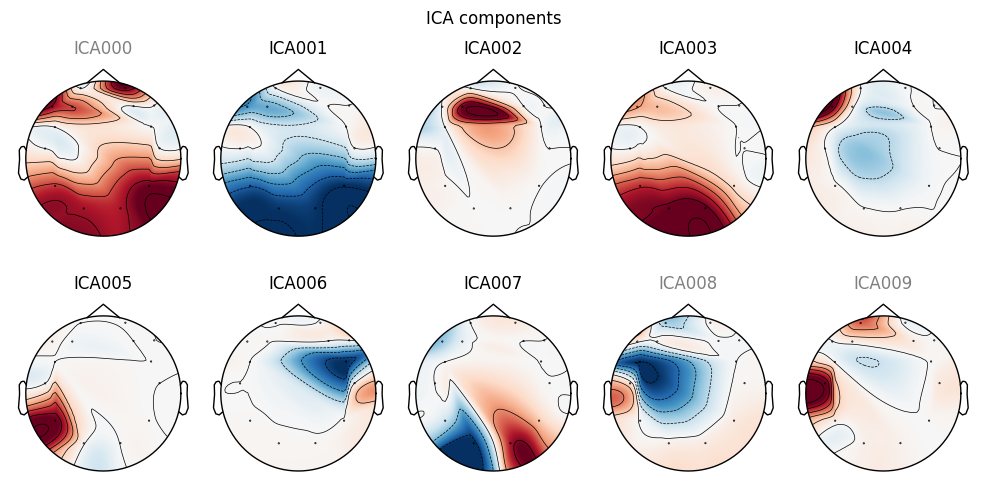

In [ ]:
ica.plot_components()

In [ ]:
ar = AutoReject(n_interpolate=[1, 2, 4],
                random_state=42,
                picks=mne.pick_types(epochs_postica.info,
                                     eeg=True,
                                     eog=False
                                    ),
                n_jobs=4,
                verbose=False
                )

epochs_clean, reject_log_clean = ar.fit_transform(epochs_postica, return_log=True)

epochs_clean

<Epochs | 635 events (all good), 0 – 5 s (baseline off), ~43.5 MB, data loaded,
 '1': 635>

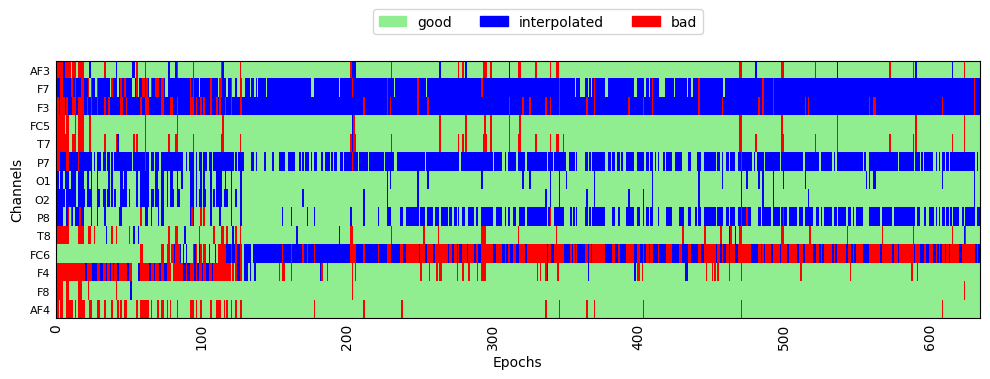

In [ ]:
fig, ax = plt.subplots(figsize=[10, 4])
reject_log_clean.plot('horizontal', aspect='auto', ax=ax)
plt.show()


In [ ]:
epochs_df = epochs_clean.to_data_frame()

epochs_dff = epochs_df.drop(['time', 'condition'], axis=1)

unique_epochs = list(epochs_dff['epoch'].unique())


In [ ]:
label_data

,state,subject,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
674888,0,subject_3,4445.128205,3962.564103,5018.461538,3829.743590,4035.384615,4308.717949,4250.769231,4049.230769,4149.743590,4313.333333,4148.205128,4280.512821,4334.871795,4084.102564
674889,0,subject_3,4445.128205,3972.307692,5024.102564,3826.666667,4035.384615,4311.794872,4257.948718,4053.846154,4155.897436,4313.846154,4147.692308,4280.512821,4334.871795,4089.230769
674890,0,subject_3,4444.615385,3975.384615,5024.102564,3825.128205,4035.384615,4317.948718,4263.076923,4057.948718,4157.435897,4314.358974,4145.641026,4281.025641,4334.871795,4097.435897
674891,0,subject_3,4443.589744,3973.846154,5031.794872,3829.230769,4035.384615,4320.000000,4266.666667,4058.461538,4161.538462,4312.820513,4145.128205,4280.000000,4334.871795,4103.076923
674892,0,subject_3,4442.051282,3982.051282,5041.025641,3831.282051,4035.384615,4324.615385,4266.153846,4059.487179,4168.205128,4314.358974,4146.153846,4281.025641,4334.871795,4110.256410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9917207,0,subject_34,4449.230769,3960.000000,5003.076923,3832.820513,4048.205128,4270.769231,4325.128205,4013.846154,4125.128205,4317.435897,4150.769231,4289.230769,4340.000000,4272.820513
9917208,0,subject_34,4448.205128,3959.487179,5008.717949,3833.846154,4045.641026,4276.410256,4327.692308,4022.051282,4127.692308,4323.076923,4150.769231,4289.230769,4340.000000,4278.974359
9917209,0,subject_34,4445.641026,3960.000000,5014.871795,3831.794872,4046.666667,4273.333333,4323.589744,4015.384615,4121.538462,4317.948718,4150.769231,4289.230769,4340.000000,4275.897436
9917210,0,subject_34,4446.666667,3959.487179,5024.102564,3828.717949,4045.128205,4274.871795,4326.153846,4014.358974,4124.615385,4311.794872,4150.769231,4289.230769,4340.000000,4272.820513


In [ ]:
labels = []

for epoch in range(len(unique_epochs)):
    start_idx = int((sfreq * tstep + 1) * epoch)
    end_idx = int(start_idx + sfreq * tstep + 1)

    if end_idx > len(label_data):
        labels.extend(label_data[start_idx:len(label_data)].tolist())
    else:
        labels.extend(label_data[start_idx:end_idx].tolist())

labels = np.array(labels)
labels = labels.reshape(-1, 1)

if len(epochs_dff) > len(labels):
    epochs_dff = epochs_dff[:len(labels)]
else:
    labels = labels[:len(epochs_dff)]

In [ ]:
epochs_dff['state']=labels

epochs_dff=epochs_dff.drop('epoch',axis=1)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

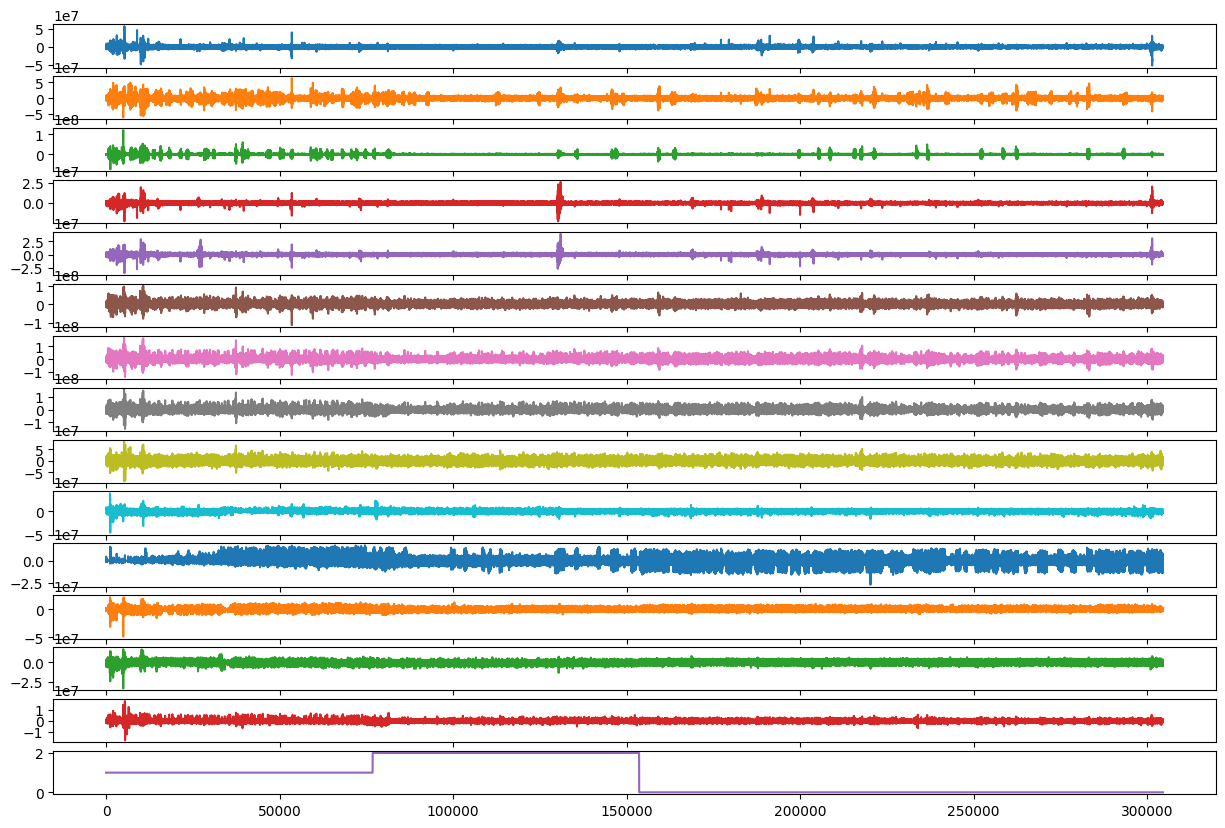

In [ ]:
epochs_dff.plot(subplots=True, figsize=(15, 10), legend=False)

## XI. Pipeline Summary:


1. Filter frequencies, Remove low frequencies (<1 Hz) as they tend to be non-stationary, remove high frequencies (>40 Hz) to eliminate noise
2. Segment data
3. Before ICA: Detect and exclude bad epochs to ensure ICA decomposition is robust.
4. ICA Step: Fit ICA on cleaner data to isolate artifact components.
5. Dynamically identify and exclude artifact-related ICA components.
6. After ICA:  Apply AutoReject to clean residual artifacts and interpolate data where necessary